# Анализ рынка заведений общественного питания Москвы

### Цели и задачи проекта

В этой работе используется датасет, содержащий в себе данные о заведениях общественного питания Москвы. Необходимо проанализировать его данные и предоставить инвесторам актуальную информацию об объектах питания в Москве, чтобы они смогли подобрать оптимальный для себя тип заведения, его расположение и т.д. для открытия новой точки.

В ходе выполнения работы ознакомимся с датасетом, проведем его предобработку и реализуем исследовательский анализ данных.

### Содержимое проекта

1. [Загрузка данных и знакомство с ними.](#1-bullet)
2. [Предобработка данных.](#2-bullet)
3. [Исследовательский анализ данных.](#3-bullet)<br>
    3.1 [Задача 1](#3.1-bullet)<br>
    3.2 [Задача 2](#3.2-bullet)<br>
    3.3 [Задача 3](#3.3-bullet)<br>
    3.4 [Задача 4](#3.4-bullet)<br>
    3.5 [Задача 5](#3.5-bullet)<br>
    3.6 [Задача 6](#3.6-bullet)<br>
    3.7 [Задача 7](#3.7-bullet)<br>
    3.8 [Задача 8](#3.8-bullet)<br>
4. [Итоговый вывод и рекомендации](#4-bullet)<br>
---

<a class="anchor" id="1-bullet"></a>
## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

Загрузим датасеты.

In [ ]:
!pip install phik==0.12.0  

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from phik import phik_matrix
import numpy as np
import seaborn as sns

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Ошибка кода. Перед отправкой проекта на проверку надо проверять тетрадку на исполнение кода без ошибок. Так как при ошибке ревьюер должен прекратить проверку и вернуть проект. 😢 <br>В этот раз я сам вставлю правильный код и перезапущу тетрадку, что бы ее можно было проверить до конца. </font>
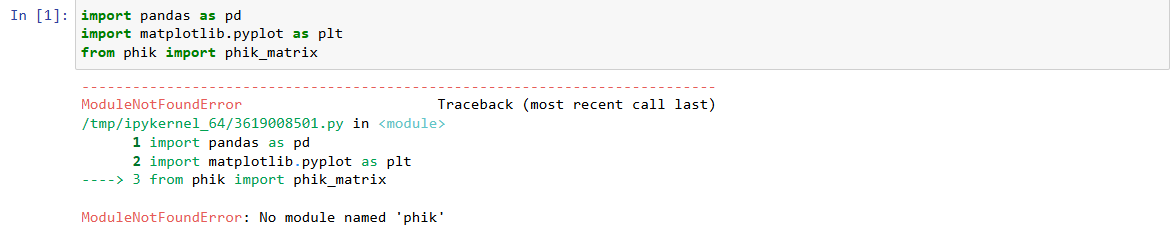

In [3]:
try:
    df_info = pd.read_csv('/datasets/rest_info.csv') 
    df_price = pd.read_csv('/datasets/rest_price.csv')
except:
    df_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv') 
    df_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv') 

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Очень хорошо! Загрузка датасетов непосредственно с сервера и все равно от куда запускается тетрадка. 👍</font>

- Познакомьтесь с данными и изучите общую информацию о них.

Ознакомимся с данными датасета rest_info.

In [4]:
df_info.shape

(8406, 9)

In [5]:
df_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
df_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


Ознакомимся с данными датасета rest_price.

In [7]:
df_price.shape

(4058, 5)

In [8]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [9]:
df_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

В результате знакомства с данными можно сделать выводы:
- размер датасета `rest_info` - 8406 строк и 9 столбцов, `rest_price` - 4058 строк и 5 столбцов;
- описания данных соответствуют фактическим данным;
- столбцы датасета `rest_info`, типы данных которых стоит изменить: 
    - `rating`: сократить разрядность, так как значения заключены в пределах пяти; 
    - `chain`: сократить разрядность, так как значения столбца могут принимать значения только 0 и 1;
    - `seats`: заменить на целочисленный, так как количество посадочных мест - целое число.
- типы данных столбцов датасета `rest_price` менять не надо;
- пропуски датасета `rest_info` встречаются в столбцах: `hours`, `seats`;
- пропуски датасета `rest_price` встречаются во всех столбцах: `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`.

При предобработке стоит обратить внимание на то, что:
- в датасете `rest_info` могут быть ошибки в столбце `chain` для маленьких сетей (из условия);
- если понадобится работать с часами работы заведений, за счет указания дней недели, с ними нельзя работать как со временем;
- в датасете `rest_price` в столбцах `middle_avg_bill`, `middle_coffee_cup` есть много пропусков (особенно в `middle_coffee_cup`). 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, исследовали общую информацию о датасетах и сделали промежуточные выводы.</font>

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [10]:
df = df_info.merge(df_price, how='left')

In [11]:
df.shape

(8406, 13)

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно объединили датасеты в одну таблицу, проверили результат.</font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Лучше перед обработкой данных делать контроль размера датасета до и после обработки. Примерно вот так:</font>

In [12]:
# Комментарий ревьюера
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
# только не надо эту копию потом использовать в проекте
temp = df.copy() 
len(temp)

8406

<a class="anchor" id="2-bullet"></a>
## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

Стиль написания названий столбцов не будем изменять, так как он уже имеет вид snake case.

Повторно проверим типы данных и изменим их.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Преобразуем типы данных столбцов `rating`, `chain`, `seats`.

In [14]:
# сократим разрядность столбца rating
df['rating'] = pd.to_numeric(df['rating'], downcast='float')

In [15]:
# сократим разрядность столбца chain
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

Проанализируем пропуски в столбце `seats`, прежде чем изменить тип.

In [16]:
round((df['seats'].isna().sum() / df.shape[0]) * 100, 3)

42.957

В столбце `seats` почти 43% пропусков.

Проверим, зависят ли пропуски от типа заведения. Возможно, есть заведения, изначально не предполагающие под собой наличие сидячих мест.

In [17]:
# создадим датафрейм для проверки
df_check = pd.DataFrame({
    'is_know_seats': df['seats'].isna(),
    'category': df['category']
})
df_check

,is_know_seats,category
0,True,кафе
1,False,ресторан
2,False,кафе
3,True,кофейня
4,False,пиццерия
...,...,...
8401,False,кафе
8402,False,кафе
8403,False,кафе
8404,False,кафе


In [18]:
# сгруппируем данные по категориям заведения
check_grouped = df_check.groupby('category')['is_know_seats'].sum()
check_grouped

category
бар,паб             297
булочная            108
быстрое питание     254
кафе               1160
кофейня             662
пиццерия            206
ресторан            773
столовая            151
Name: is_know_seats, dtype: int64

<AxesSubplot:title={'center':'Проверка зависимости отсутствия информации о количестве мест в заведении от типа заведения'}, xlabel='Тип заведения', ylabel='Количество заведений без информации'>

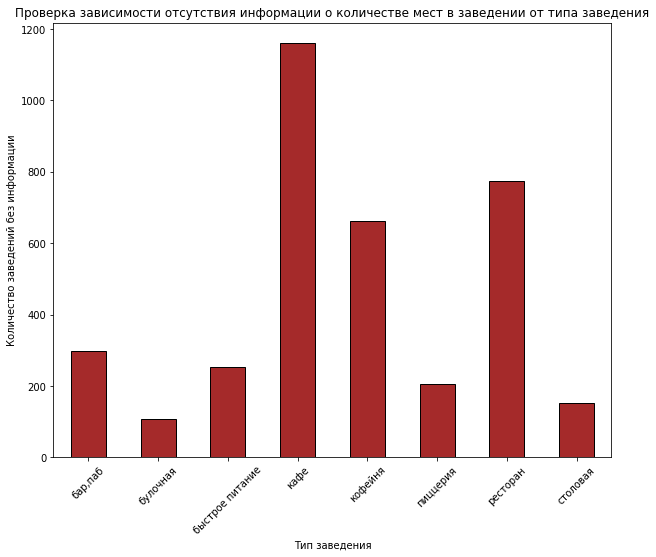

In [19]:
check_grouped.plot(kind='bar', xlabel='Тип заведения', ylabel='Количество заведений без информации', title='Проверка зависимости отсутствия информации о количестве мест в заведении от типа заведения', color='brown', edgecolor='black', rot=45, figsize=(10, 8))

По графику можно увидеть, что количество пропусков в столбце с количеством мест не зависит от типа заведения.

Вероятно, ни от каких других столбцов датафрейма не зависит, указана ли информация о количестве мест в заведении. 

Так как в датафрейме нет информации, которая помогала бы выявить логику пропусков, данные точно имеют тип не MAR. Нельзя точно сказать, являтся ли пропуски MNAR или MCAR.

Так как пропусков много, заменим их значение-индикатором. Проверим минимальное значение в столбце, чтобы убедиться, что в столбец не были по ошибке занесены отрицательные данные.

In [20]:
df['seats'].min()

0.0

Заменим все пропуски значением-индикатором, равным -1.

In [21]:
df['seats'] = df['seats'].fillna(-1)

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Допустимая замена пропусков заглушками (значением-индикатором). Только при анализе заглушки надо будет отфильтровывать.</font><br>
<font color='DarkMagenta'>👉 Но надо иметь в виду, что правильно построить матрицу корреляции по столбцам с заглушками не удастся, так как заглушки искажают анализ, а при фильтрации заглушки в одном столбце теряются значимые данные в других столбцах. По этому в этой задаче необходимо будет обратно заменить заглушки на пропуски, пропуски не мешают расчету корреляции и анализу.</font>

In [22]:
# преобразуем тип столбца seats
df['seats'] = df['seats'].astype('int64')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Можно еще понизить разрядность числовых данных с 64 до 32, примерно вот так:<br>
`for column in ['middle_avg_bill','middle_coffee_cup']:`<br>
&nbsp;&nbsp;&nbsp;&nbsp;`df[column] = pd.to_numeric(df[column], downcast='float')`</font>

Понизим разрядность числовых данных столбцов `middle_avg_bill`, `middle_coffee_cu` с 64 до 32.

In [23]:
for column in ['middle_avg_bill','middle_coffee_cup']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              8406 non-null   int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(3), int64(1), int8(1), object(8)
memory usage: 763.4+ KB


<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Понижение разрядности численных типов данных (например, переход с `float64` на `float32`) часто используется в машинном обучении и обработке больших объемов данных для достижения нескольких целей:<br>
    
<b>Когда имеет смысл уменьшать разрядность данных (`float64 → float32`, `int64 → int32`):</b><br><br>
   
- Экономия памяти. Тип данных типа `float64` занимает вдвое больше места в оперативной памяти по сравнению с типом `float32`. Для больших наборов данных разница становится существенной. Например, для набора данных объемом 1 миллион записей, каждая запись с одним столбцом типа `float64` займет около 8 Мб памяти, тогда как с использованием `float32` объем снизится примерно до 4 Мб.<br>
<i>Пример:</i> Работа с моделями глубокого обучения требует много памяти, особенно при тренировке крупных моделей на GPU, где экономия памяти важна.

- Увеличение скорости вычислений. Современные процессоры и видеокарты поддерживают работу с данными типа `float32` быстрее, чем с `float64`. Поэтому снижение разрядности позволяет ускорить обработку данных, особенно если выполняются операции линейной алгебры, векторизации и оптимизации.<br>
<i>Пример:</i> TensorFlow и PyTorch автоматически используют форматы с плавающей точкой половинной точности (`float16`), поскольку современные GPU эффективно работают именно с такими данными.<br>

- Минимизация эффекта избыточной точности. Многие алгоритмы машинного обучения и обработки данных вполне нормально функционируют даже при уменьшении точности чисел с плавающей точкой. Обычно разряды младших значащих цифр значений типов `float64` практически не влияют на итоговые результаты моделирования.<br>
<i>Пример:</i> Большинство приложений в Data Science, включая классификацию изображений, регрессию временных рядов и обучение нейронных сетей, успешно работают с типами `float32`.

<b>Когда нельзя снижать разрядность:</b>
- Необходимость высокой точности расчетов. Некоторые приложения требуют максимальной точности расчетов, например финансовые расчеты, научные исследования, медицинские системы диагностики, где незначительные погрешности недопустимы.
- Работа с большими диапазонами чисел. Тип `float32` ограничен пределами числа порядка ±3.4×10³⁸, тогда как диапазон `float64` значительно шире (~±1.8×10³⁰⁸). Если в наборе данных присутствуют значения, выходящие за пределы возможностей формата `float32`, уменьшение разрядности приведет к потере данных.
- Операции, чувствительные к накоплению ошибок округления. В некоторых сложных моделях машинного обучения ошибка накапливается постепенно при многократных итерациях. Переход на меньшую точность может привести к заметному снижению качества модели.

Таким образом, снижение разрядности полезно там, где требуются производительность и экономичность вычислительных ресурсов, а потери точности минимальны или допустимы. Но в тех ситуациях, где высокая точность критична, использование полной разрядности обязательно.
</font>

Все типы данных столбцов были корректно преобразованы.

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [25]:
# посчитаем абсолютное количество пропущенных значений
df.isna().sum().sort_values()

id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
seats                   0
hours                 536
avg_bill             4590
price                5091
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [26]:
# посчитаем относительное количество пропущенных значений
round((df.isna().sum() / df.shape[0]) * 100, 2).sort_values()

id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
rating                0.00
chain                 0.00
seats                 0.00
hours                 6.38
avg_bill             54.60
price                60.56
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что пропуски изучены в абсолютных и относительных значениях.</font><br>
<font color='DarkMagenta'>👉 Можно вот так вывести информацию о пропусках:</font>

In [27]:
# Комментарий ревьюера
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0].sort_values(by='Кол-во пропусков')
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
avg_bill,4590,0.5460
price,5091,0.6056
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Не проанализированы пропуски в датасете, не сделаны предположения об их причинах и предложений по обработке пропусков.</font>

С учетом обработки пропусков в `seats`, пропуски так же содержатся в столбцах:
- `hours`;
- `price`;
- `avg_bill`;
- `middle_avg_bill`;
- `middle_coffee_cup`.

Наименьшее количество пропусков содержится в столбце `hours`, наибольшее - в столбце `middle_coffee_cup`.

Предположения о причинах пропусков:
- возможно, пропуски в `hours` имеют тип MNAR и они не были указаны владельцами заведений из-за факторов, которых нет в наборе данных. Это могут быть маленькие заведения, владельцы которых не знают о подобной функции добавления времени работы заведения, либо за счет маленького потока людей данные добавить было некому;
- возможно, пропуски в `price` и `avg_bill` так же имеют тип MNAR и появляются из-за того, что на сайты владельцами либо посетителями не была добавлена информация о меню/ценах на блюда;
- пропуски в `middle_avg_bill`, `middle_coffee_cup` встречаются, потому что они строятся по столбцу `avg_bill`, в котором есть пропуски. Так же из-за того, что эти столбцы строятся только по определенным строкам `avg_bill` (начинающихся с «Средний счёт» или «Цена одной чашки капучино»).

Проверим, какие столбцы из столбцов с пропусками будут использоваться в дальнейшем анализе. Получим:
- `hours`: для создания столбца `is_24_7`;
- `price`: для задания 6;
- `middle_avg_bill`: для задания 8.

На основе проверки сделаем предложения по обработке пропусков:
- пропуски в столбцах, не используемых для дальнейшего анализа (`avg_bill`, `middle_coffee_cup`), обрабатывать не будем;
- столбец `hours`: так как нельзя восстановить время работы заведений, заменим пропуски значением-индикатором - пустой строкой;
- столбцы `price`и `middle_avg_bill`: количество пропусков очень большое, данные будут сильно искажены, если заменить их (например, заполнение наиболее частыми значениями в группах не подойдет). Их так же заменим значениями-индикаторами (пустой строкой и -1 соответственно). 

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Хорошо, исправили.</font>

Обработаем пропуски столбца `hours`. 

In [28]:
df['hours'] = df['hours'].fillna("")

Обработаем пропуски столбцов `price`и `middle_avg_bill`. 

In [29]:
df['price'] = df['price'].fillna("")

In [30]:
# проверим минимальное значение в столбце middle_avg_bill
sorted(df['middle_avg_bill'].unique())[:2]

[nan, 0.0]

In [31]:
# заменим значением-индикатором -1
df['middle_avg_bill'] = df['middle_avg_bill'].fillna(-1)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              8406 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              8406 non-null   int64  
 9   price              8406 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    8406 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(3), int64(1), int8(1), object(8)
memory usage: 763.4+ KB


- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Следовало проверить уникальные значения в категориальных столбцах до их преобразования.</font>

Создадим список с названиями категориальных столбцов.

In [33]:
# оставим в списке названия только категориальных столбцов
columns_categor = list(df.columns)
for_delete = ['id', 'rating', 'chain', 'seats', 'middle_avg_bill', 'middle_coffee_cup']
for column in for_delete:
    columns_categor.remove(column)
columns_categor

['name', 'category', 'address', 'district', 'hours', 'price', 'avg_bill']

Проверим уникальные значения в категориальных данных.

In [34]:
print('Unique values:')
for column in columns_categor:
    print(f'{column}: {df[column].unique()[:10]}', end='\n\n')

Unique values:
name: ['WoWфли' 'Четыре комнаты' 'Хазри' 'Dormouse Coffee Shop' 'Иль Марко'
 'Sergio Pizza' 'Огни города' 'Mr. Уголёк' 'Donna Maria' 'Готика']

category: ['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая']

address: ['Москва, улица Дыбенко, 7/1' 'Москва, улица Дыбенко, 36, корп. 1'
 'Москва, Клязьминская улица, 15' 'Москва, улица Маршала Федоренко, 12'
 'Москва, Правобережная улица, 1Б' 'Москва, Ижорская улица, вл8Б'
 'Москва, Клязьминская улица, 9, стр. 3'
 'Москва, Дмитровское шоссе, 107, корп. 4' 'Москва, Ангарская улица, 39'
 'Москва, Левобережная улица, 12']

district: ['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ']

hours: ['ежедневно, 10:00

Запомним количество дубликатов до нормализации данных.

In [35]:
duplicates = df.duplicated().sum()
duplicates

0

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, что проверены явные дубликаты, иногда они сильно искажают анализ.</font>

Проведем поиск неявных дубликатов. Для этого поработаем с регистром категориальных данных.

Запомним кол-во уникальных значений в столбцах до нормализации.

In [36]:
num_unique_before = [df[column].nunique() for column in columns_categor]
num_unique_before

[5614, 8, 5753, 9, 1308, 5, 897]

In [37]:
for column in columns_categor:
    df[column] = df[column].str.lower().str.strip()

Запомним кол-во уникальных значений в столбцах после нормализации.

In [38]:
num_unique_after = [df[column].nunique() for column in columns_categor]
num_unique_after

[5512, 8, 5752, 9, 1308, 5, 897]

Проверим, изменилось ли кол-во уникальных значений после нормализации.

In [39]:
diff = [num_unique_before[i] - num_unique_after[i] for i in range(len(num_unique_after))]
print_result = pd.DataFrame({'column_categor': columns_categor, 'diff': diff})
print_result = print_result[print_result['diff'] > 0]
print_result

,column_categor,diff
0,name,102
2,address,1


Количество уникальных значений изменилось в столцбах `name`, `address`. Проверим, добавились ли после обработки пробелов и регистра новые, теперь уже явные дубликаты.

In [40]:
df.duplicated().sum()

0

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Не проверены неявные (неполные) дубликаты. Какие столбцы датасета могут содержать уникальные значения, видимо это название заведения и его адрес. Следовательно, неявные дубликаты следует проверять одновременно по этим двум столбцам, предварительно надо нормализовать данные к одному регистру и удалить конечные пробелы.</font>

<font color='DarkBlue'><b>Комментарий студента</b></font><br>
Подскажите, пожалуйста, я же правильно понимаю, что проверка неявных дубикатов по столбцам с названием заведения и адресом следует только из логический рассуждений (потому что не может быть 2 и более строк с совпадающими названиями заведения и адресами одновременно)?

Правильно ли я понимаю, что в том числе мы модифицируем регистр и работаем с пробелами у категориальных данных, чтобы обнаружить неявные дубликаты?

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 При проверке на неявные дубликаты всегда в датасете выбираем комбинацию столбцов, значения которых должны быть уникальны. И нормализуем данные в этих столбцах, что бы исключить разное написание названия или адреса.</font>

Новые явные дубликаты добавлены не были. Продолжим проверку неявных дубликатов, для этого проверим значения одновременно в столбцах `name`, `address`.

In [41]:
df.duplicated(subset=['name', 'address']).sum()

4

В данных есть 4 неявных дубликата. 

In [42]:
# посмомтрим на первые строки и их дубликаты
df[df.duplicated(subset=['name', 'address'], keep=False) == True]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,-1,,NaN,-1.0,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,-1,,NaN,-1.0,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,,NaN,-1.0,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,,NaN,-1.0,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,,NaN,-1.0,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,,NaN,-1.0,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,,NaN,-1.0,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,,4.1,0,276,,NaN,-1.0,NaN


Проанализируем строки с неявными дубликатами:
- строки с названием заведения `кафе` и адресом `москва, парк ангарские пруды`: различия строк во времени работы. Ранее пропуски в столбце со временем работы заменялись пустой строкой. В данном случае удалим строку-дубликат и в оставшейся заменим время работы пустой строкой, так как неизвестно, какое время корректное;
- строки с названием заведения `more poke` и адресом `москва, волоколамское шоссе, 11, стр. 2`: различия строк в типе заведения (сетевое/несетевое). Удалим строку-дубликат и присвоим тип "сетевое", если в датафрейме имеются 2 и более заведения с таким же названием, иначе - "несетевое";
- строки с названием заведения `раковарня клешни и хвосты` и адресом `москва, проспект мира, 118`: различия строк в категории заведения, времени работы, типе заведения. Удалим строку-дубликат и присвоим тип "сетевое", если в датафрейме имеются 2 и более заведения с таким же названием, иначе - "несетевое"; время работы заменим на пустую строку-индикатор; если заведение сетевое, категорию выберем как у заведений с таким же названием по другим адресам, иначе - оставим как есть;
- строки с названием заведения `хлеб да выпечка` и адресом `москва, ярцевская улица, 19`: различия строк в категории заведения, времени работы, типе заведения. Удалим строку-дубликат и присвоим тип "сетевое", если в датафрейме имеются 2 и более заведения с таким же названием, иначе - "несетевое"; время работы оставим, так как в строке-дубликате вместо времени работы был пропуск; если заведение сетевое, категорию выберем как у заведений с таким же названием по другим адресам, иначе - оставим как есть.

In [43]:
# удалим неявные дубликаты
df = df.drop_duplicates(subset=['name', 'address'])

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Хорошо, обработали дубликаты.</font>

Работа со строкой с названием заведения `кафе` и адресом `москва, парк ангарские пруды`.

In [44]:
df.loc[(df['name']  == 'кафе') & (df['address']  == 'москва, парк ангарские пруды'), 'hours'] = ''
df[(df['name']  == 'кафе') & (df['address']  == 'москва, парк ангарские пруды')]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,,3.2,0,-1,,NaN,-1.0,NaN


Работа со строкой с названием заведения `more poke` и адресом `москва, волоколамское шоссе, 11, стр. 2`. Проверим сетевое ли заведение.

In [45]:
df[df['name'] == 'more poke']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,,NaN,-1.0,NaN
6088,1cd73aca53414d65a7744da3d1c93832,more poke,ресторан,"москва, духовской переулок, 19",южный административный округ,"ежедневно, 10:00–22:00",4.4,1,-1,,NaN,-1.0,NaN


Заведение сетевое, присвоим соответствующий тип.

In [46]:
df.loc[(df['name']  == 'more poke') & (df['address']  == 'москва, волоколамское шоссе, 11, стр. 2'), 'chain'] = 1
df.loc[(df['name']  == 'more poke') & (df['address']  == 'москва, волоколамское шоссе, 11, стр. 2')] 

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,1,188,,NaN,-1.0,NaN


Работа со строкой с названием заведения `раковарня клешни и хвосты` и адресом `москва, проспект мира, 118`. Проверим сетевое ли заведение.

In [47]:
df[df['name'] == 'раковарня клешни и хвосты']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,,NaN,-1.0,NaN
7270,f2e3eb711fe040c3a2c03e18a6783b05,раковарня клешни и хвосты,"бар,паб","москва, братиславская улица, 12",юго-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.9,1,40,средние,цена бокала пива:150–250 ₽,-1.0,NaN


Заведение сетевое, присвоим соответствующий тип. У заведения из сети категория "бар, паб". Поставим такую же категорию для нашей строки. Заменим время на строку-индикатор.

In [48]:
df.loc[(df['name']  == 'раковарня клешни и хвосты') & (df['address']  == 'москва, проспект мира, 118'), 'chain'] = 1
df.loc[(df['name']  == 'раковарня клешни и хвосты') & (df['address']  == 'москва, проспект мира, 118'), 'category'] = 'бар,паб'
df.loc[(df['name']  == 'раковарня клешни и хвосты') & (df['address']  == 'москва, проспект мира, 118'), 'hours'] = ''
df.loc[(df['name']  == 'раковарня клешни и хвосты') & (df['address']  == 'москва, проспект мира, 118')] 

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,,4.4,1,150,,NaN,-1.0,NaN


Работа со строкой с названием заведения `хлеб да выпечка` и адресом `москва, ярцевская улица, 19`. Проверим сетевое ли заведение.

In [49]:
df[df['name'] == 'хлеб да выпечка']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,,NaN,-1.0,NaN
7937,d1bb31bf8e1b45f8a2db20182836e3ac,хлеб да выпечка,кофейня,"москва, каширское шоссе, 61г",южный административный округ,"ежедневно, 09:00–22:00",4.5,1,-1,,NaN,-1.0,NaN


Заведение сетевое, присвоим соответствующий тип. У заведения из сети категория "кофейня". Поставим такую же категорию для нашей строки.

In [50]:
df.loc[(df['name']  == 'хлеб да выпечка') & (df['address']  == 'москва, ярцевская улица, 19'), 'chain'] = 1
df.loc[(df['name']  == 'хлеб да выпечка') & (df['address']  == 'москва, ярцевская улица, 19'), 'category'] = 'кофейня'
df.loc[(df['name']  == 'хлеб да выпечка') & (df['address']  == 'москва, ярцевская улица, 19')] 

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,кофейня,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,,NaN,-1.0,NaN


Неявные дубликаты были обработаны.

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

Посмотрим обозначение ежедневной и круглосуточной работы в датасете.

In [51]:
df['hours'].head(15)

0                                ежедневно, 10:00–22:00
1                                ежедневно, 10:00–22:00
2     пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...
3                                ежедневно, 09:00–22:00
4                                ежедневно, 10:00–22:00
5                                ежедневно, 10:00–23:00
6                     пн 15:00–04:00; вт-вс 15:00–05:00
7     пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...
8                                ежедневно, 10:00–22:00
9                                ежедневно, 12:00–00:00
10                             ежедневно, круглосуточно
11                               ежедневно, 10:00–21:00
12                                    вт-сб 09:00–18:00
13                               ежедневно, 08:00–22:00
14                               ежедневно, 13:00–00:00
Name: hours, dtype: object

Можно заметить, что подходящий для нового столбца вариант - "ежедневно, круглосуточно".

Создадим столбец `is_24_7` по столбцу `hours`.

In [52]:
def create_column(row):
    if row['hours'] == 'ежедневно, круглосуточно':
        return True
    return False


df['is_24_7'] = df.apply(create_column, axis=1)

Проверим корректность создания столбца.

In [53]:
df_hours_24_7 = df[['hours', 'is_24_7']]
df_hours_24_7.head()

,hours,is_24_7
0,"ежедневно, 10:00–22:00",False
1,"ежедневно, 10:00–22:00",False
2,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,"ежедневно, 09:00–22:00",False
4,"ежедневно, 10:00–22:00",False


In [54]:
df_hours_24_7[df_hours_24_7['hours'] == 'ежедневно, круглосуточно'].head()

,hours,is_24_7
10,"ежедневно, круглосуточно",True
17,"ежедневно, круглосуточно",True
19,"ежедневно, круглосуточно",True
24,"ежедневно, круглосуточно",True
49,"ежедневно, круглосуточно",True


Новый столбец `is_24_7` был корректно создан.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Корректно создан столбец с бинарным признаком ежедневной и круглосуточной работы заведения и других.</font>

In [55]:
# Комментарий ревьюера
df['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [56]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

В ходе выполнения работы были:
- Изменены типы данных столбцов `rating`, `chain`, `seats`. Понижена раздрядность столбцов `middle_avg_bill`, `middle_coffee_cup`;
- Проанализированы причины пропусков во всех столбцах, предложены способы работы с пропусками. В столбцах `seats`, `hours`, `price`, `middle_avg_bill` проведены замены пропусков значениями-индикаторами;
- Нормализованы категориальные данные;
- Выявлено отсутствие явных дубликатов;
- Выявлено наличие 4 неявных дубликатов. Проведен анализ строк-неявных дубликатов, редактирование оставшихся после удаления строк, чтобы данные были не искажены.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Вывод необходимо будет переделать после исправления ошибок анализа и предобработки.</font>

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="3-bullet"></a>
## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---
<a class="anchor" id="3.1-bullet"></a>
### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

Сгруппируем заведения по категориям и посчитаем абсолютное количество заведений в каждой из категорий. 

In [57]:
grouped_category_abs = df.groupby('category')['name'].count().sort_values()
grouped_category_abs

category
булочная            255
столовая            315
быстрое питание     603
пиццерия            633
бар,паб             765
кофейня            1414
ресторан           2041
кафе               2376
Name: name, dtype: int64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Правильно было бы проверить еще распределение заведений в относительных значениях, для этого стоило воспользоваться методом `.value_counts()` с параметром `normalize=True`.</font>
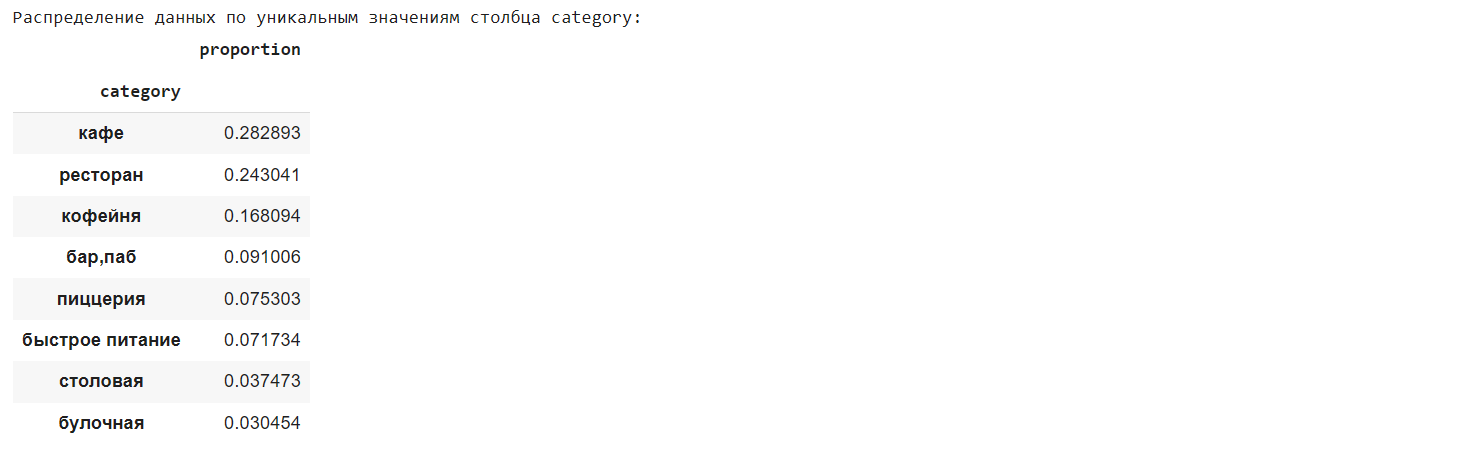

Сгруппируем заведения по категориям и посчитаем относительное количество заведений в каждой из категорий. 

In [58]:
grouped_category_rel = df['category'].value_counts(normalize=True).sort_values()
grouped_category_rel

булочная           0.030350
столовая           0.037491
быстрое питание    0.071769
пиццерия           0.075339
бар,паб            0.091050
кофейня            0.168293
ресторан           0.242918
кафе               0.282790
Name: category, dtype: float64

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Стандартный подход к анализу данных, смотрим абсолютные и относительные значения. Если какие-то значения выводим прямо на диаграммах, то в табличном виде можно не показывать.<br>
Абсолютные значения отвечают на вопрос: «Сколько?»<br>
Относительные значения отвечают на вопрос: «Какую часть?»<br>
Вместе они дают полную картину:<br>
- Где сосредоточены основные игроки.<br>
- Какие категории перспективны для развития.<br>
- Как меняется структура рынка с течением времени.<br>
    
Это особенно важно для бизнес-планирования, анализа конкуренции и прогнозирования трендов.<br>
</font>

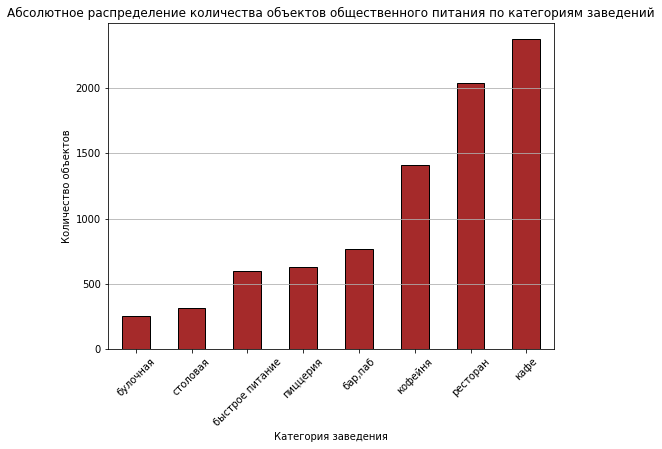

In [59]:
grouped_category_abs.plot(kind='bar', xlabel='Категория заведения', ylabel='Количество объектов', title='Абсолютное распределение количества объектов общественного питания по категориям заведений', color='brown', edgecolor='black', figsize=(8, 6), rot=45).grid(axis='y')

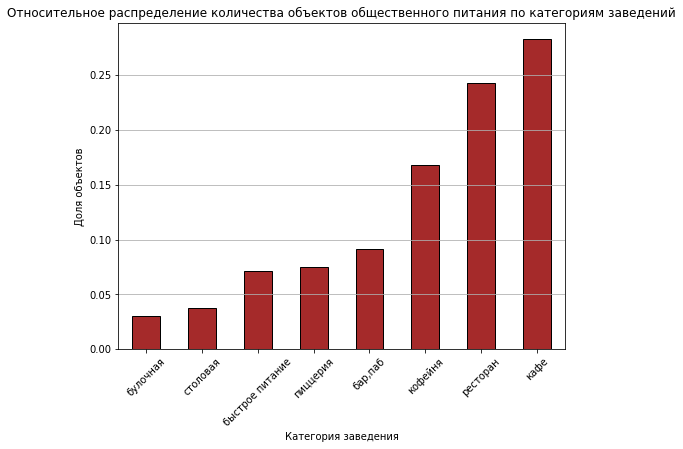

In [60]:
grouped_category_rel.plot(kind='bar', xlabel='Категория заведения', ylabel='Доля объектов', title='Относительное распределение количества объектов общественного питания по категориям заведений', color='brown', edgecolor='black', figsize=(8, 6), rot=45).grid(axis='y')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошая визуализация и правильно, что оси подписаны и есть название графика.</font>

Наиболее популярной категорией заведений является `кафе`, которому присуще примерно 2350 заведений (примерно 28%), наименее популярной - `булочная` - примерно 250 заведений (примерно 2,5%). 

В целом количество заведений довольно разнозненно. Примерно одинаковое количество присуще `булочной` и `столовой` (около 3%), заведениям типа `быстрое питание`, `пиццерия` (около 7,5%).

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, что анализ заканчивается промежуточным выводом с описанием полученных результатов. </font>

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.2-bullet"></a>
### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

Исследуем абсолютное распределение количества заведений по административным районам Москвы.

In [61]:
grouped_district_abs = df.groupby('district')['name'].count().sort_values()
grouped_district_abs = grouped_district_abs.reset_index()
grouped_district_abs

,district,name
0,северо-западный административный округ,409
1,юго-западный административный округ,709
2,юго-восточный административный округ,714
3,восточный административный округ,798
4,западный административный округ,850
5,северо-восточный административный округ,890
6,южный административный округ,892
7,северный административный округ,898
8,центральный административный округ,2242


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Не проверили распределение по административным районам в относительных значениях, для этого стоило воспользоваться методом `.value_counts()` с параметром `normalize=True`.</font>

Исследуем относительное распределение количества заведений по административным районам Москвы.

In [62]:
grouped_district_rel = df['district'].value_counts(normalize=True).sort_values()
grouped_district_rel

северо-западный административный округ     0.048679
юго-западный административный округ        0.084385
юго-восточный административный округ       0.084980
восточный административный округ           0.094977
западный административный округ            0.101166
северо-восточный административный округ    0.105927
южный административный округ               0.106165
северный административный округ            0.106879
центральный административный округ         0.266841
Name: district, dtype: float64

In [63]:
# Старый код

# Сократим названия административных районов, убрав уточнение "административный округ".
# grouped_district['district'] = grouped_district['district'].str.replace('административный округ', '')
# grouped_district

In [64]:
# Визуализируем распределение количества заведений по административным районам Москвы.

# grouped_district.plot(kind='bar', x = 'district', y='name', xlabel='Административный район', ylabel='Количество объектов', title='Зависимость количества объектов общественного питания от административного района', color='brown', edgecolor='black', figsize=(8, 6), rot=45, legend=False).grid(axis='y')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Следовало использовать столбчатую диаграмму с горизонтальным расположением, так как метки по районам очень длинные, примерно вот так:</font>
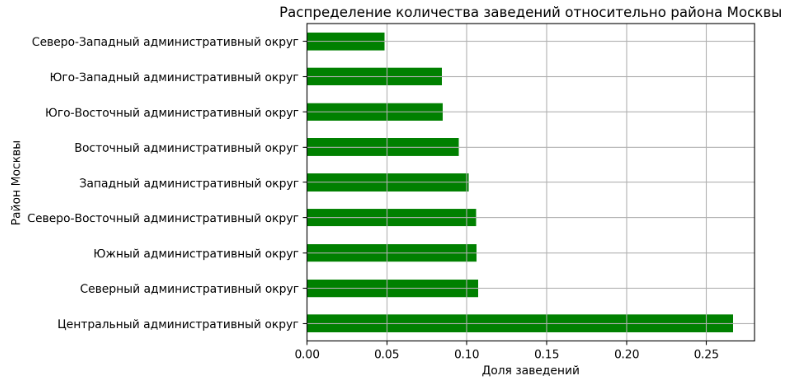

Визуализируем абсолютное и относительное распределения количества заведений по административным районам Москвы.

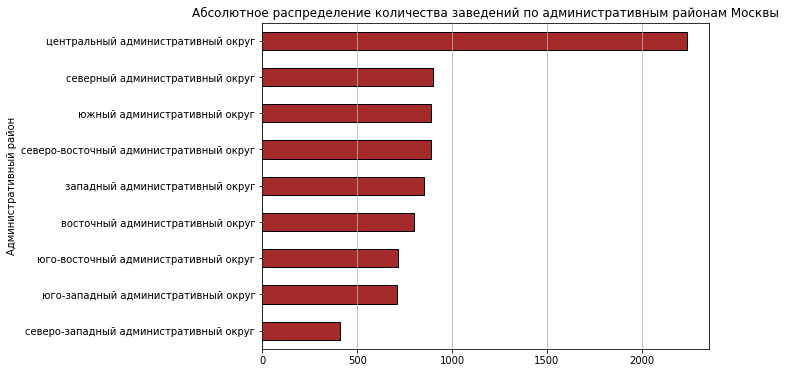

In [65]:
grouped_district_abs.plot(kind='barh', x = 'district', y='name', xlabel='Административный район', ylabel='Количество объектов', title='Абсолютное распределение количества заведений по административным районам Москвы', color='brown', edgecolor='black', figsize=(8, 6), rot=0, legend=False).grid(axis='x')

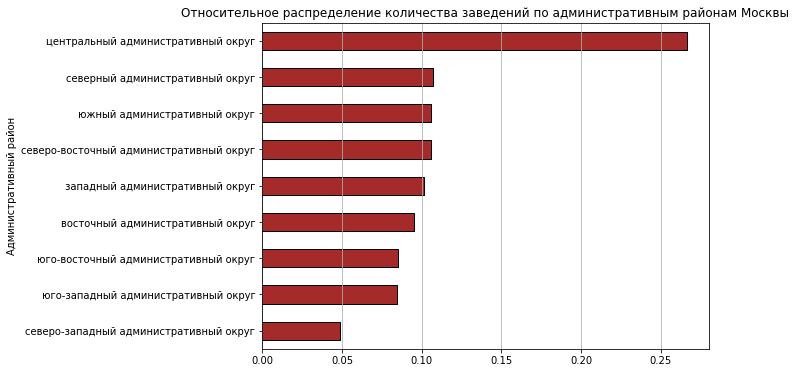

In [66]:
grouped_district_rel.plot(kind='barh', x = 'district', y='name', xlabel='Административный район', ylabel='Количество объектов', title='Относительное распределение количества заведений по административным районам Москвы', color='brown', edgecolor='black', figsize=(8, 6), rot=0, legend=False).grid(axis='x')

Наибольшее количество заведений присуще центральному району (примерно 2200, 27%), наименьшее - северо-западному, примерно 400 (4%). В пределах от 700 до 900 сосредоточено количество заведений во всех остальных районах.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что анализ заканчивается промежуточным выводом с описанием полученных результатов.</font>

Исследуем распределение заведений каждой категории в Центральном административном округе Москвы.

Выберем все заведения, расположенные в центре.

In [67]:
# посмотрим правильное название центрального административного округа
df['district'].unique()

array(['северный административный округ',
       'северо-восточный административный округ',
       'северо-западный административный округ',
       'западный административный округ',
       'центральный административный округ',
       'восточный административный округ',
       'юго-восточный административный округ',
       'южный административный округ',
       'юго-западный административный округ'], dtype=object)

Отберем заведения, находящиеся в центре, сгруппируем по категориям.

In [68]:
df_center = df[df['district'] == 'центральный административный округ']
grouped_category_center_abs = df_center.groupby('category')['name'].count().sort_values()
grouped_category_center_abs

category
булочная            50
столовая            66
быстрое питание     87
пиццерия           113
бар,паб            364
кофейня            428
кафе               464
ресторан           670
Name: name, dtype: int64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Здесь то же стоило добавить анализ заведений в ЦАО в относительных значениях.</font>

Посмотрим так же относительное распределение категорий заведений в Центральном административном округе.

In [69]:
grouped_category_center_rel = df_center['category'].value_counts(normalize=True).sort_values()
grouped_category_center_rel

булочная           0.022302
столовая           0.029438
быстрое питание    0.038805
пиццерия           0.050401
бар,паб            0.162355
кофейня            0.190901
кафе               0.206958
ресторан           0.298840
Name: category, dtype: float64

Визуализируем распределение заведений каждой категории в Центральном административном округе Москвы.

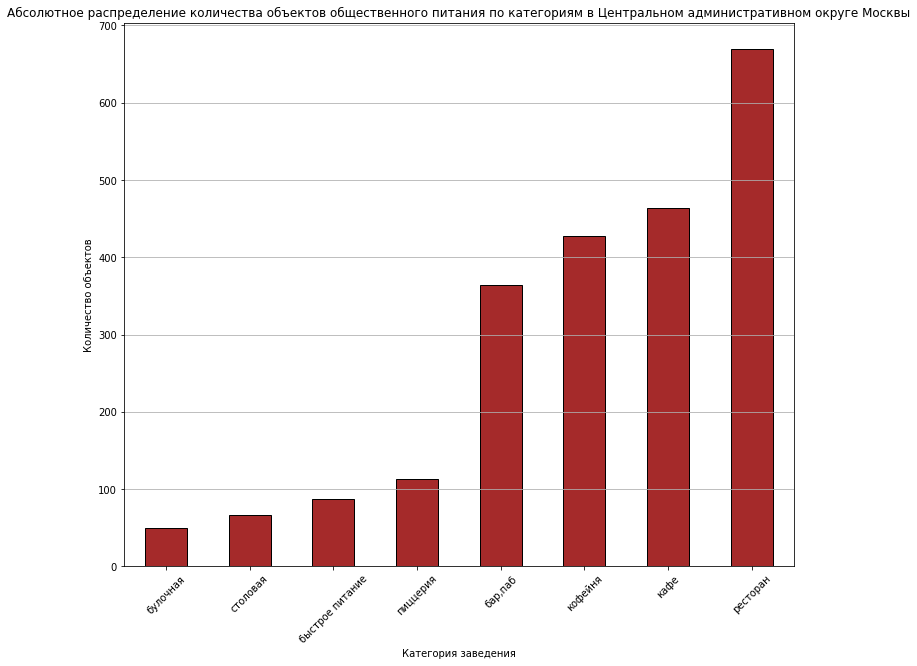

In [70]:
grouped_category_center_abs.plot(kind='bar', xlabel='Категория заведения', ylabel='Количество объектов', title='Абсолютное распределение количества объектов общественного питания по категориям в Центральном административном округе Москвы', color='brown', edgecolor='black', figsize=(12, 10), rot=45).grid(axis='y')

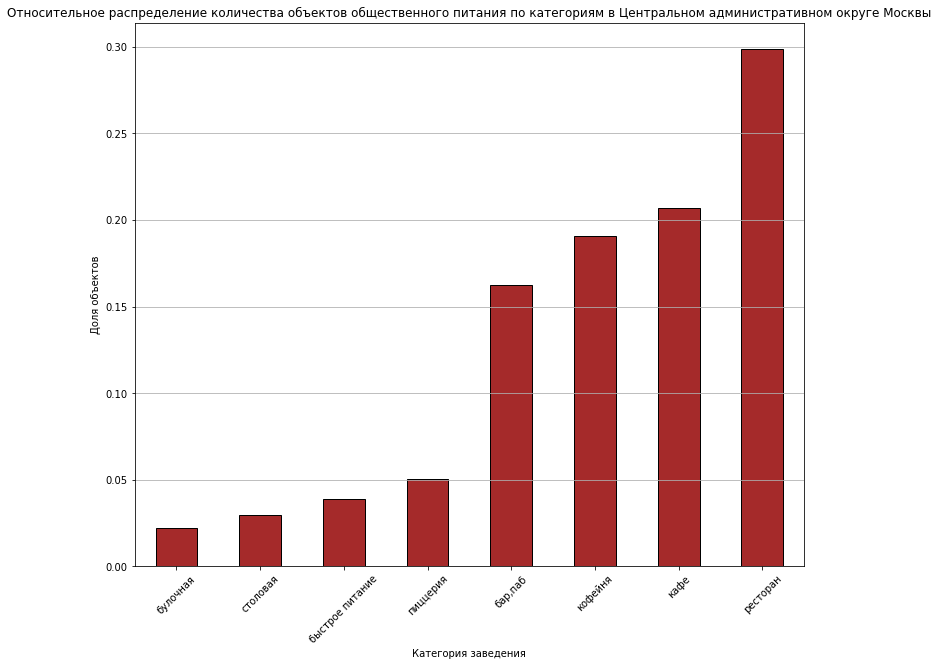

In [71]:
grouped_category_center_rel.plot(kind='bar', xlabel='Категория заведения', ylabel='Доля объектов', title='Относительное распределение количества объектов общественного питания по категориям в Центральном административном округе Москвы', color='brown', edgecolor='black', figsize=(12, 10), rot=45).grid(axis='y')

В Центральном административном округе Москвы:
- Наиболее популярные заведения - рестораны (около 660, 30%);
- Наименее популярные заведения - булочные (около 50, 2.5%);
- Количество баров и пабов, кофеен и кафе значительно больше количества столовых, заведений быстрого питания и пиццерий.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что анализ заканчиваем промежуточным выводом с описанием полученных результатов.</font>
<br><font color='DarkMagenta'>👉 Следовало отметить различие в топ категориях в ЦАО и по всем округам (задание 1).</font>

Можно заметить, что в Центральном административном округе наиболее частыми заведениями являются рестораны, а также кафе и кофейны, которых примерно на 10-15% меньше количества ресторанов. В то время по всем округам первое место занимают кафе, на 5% меньше - рестораны и на 5% меньше ресторанов - кофейни. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.3-bullet"></a>
### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [72]:
# старый код

# Изучим соотношение сетевых и несетвых заведений по всем данным.
# grouped_chain = df.groupby('chain')['name'].count()
# grouped_chain

In [73]:
# grouped_chain.plot(kind='bar', xlabel='Является ли заведение сетевым', ylabel='Количество заведений', title='Соотношение сетевых и несетевых заведений', color='brown', edgecolor='black', rot=0).grid(axis='y')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Здесь анализ необходимо проводить по распределению сетевых и не сетевых заведений в относительных значениях, для этого, как я указывал выше, необходимо воспользоваться методом `.value_counts()` с параметром `normalize=True`. Соответственно, анализ необходимо визуализировать диаграммой, примерно вот так:</font>
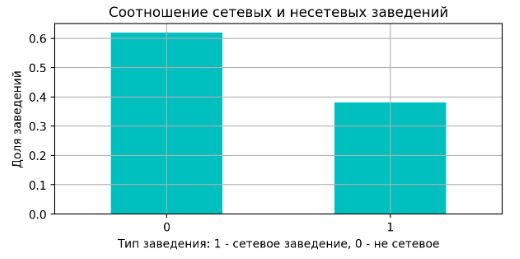

Найдем относительное распределение количества сетевых и несетвых заведений.

In [74]:
grouped_chain_rel = df['chain'].value_counts(normalize=True)
grouped_chain_rel

0    0.618543
1    0.381457
Name: chain, dtype: float64

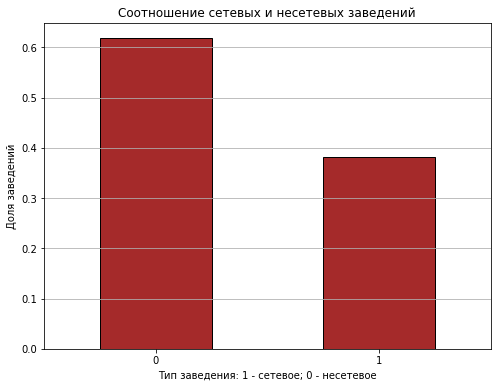

In [75]:
grouped_chain_rel.plot(kind='bar', xlabel='Тип заведения: 1 - сетевое; 0 - несетевое', ylabel='Доля заведений', title='Соотношение сетевых и несетевых заведений', color='brown', edgecolor='black', rot=0, figsize=(8, 6)).grid(axis='y')

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Правильное решение.</font>

Даже с учетом того, что в столбце chain по условию могут встречаться ошибки, можно заметить, что количество несетевых заведений примерно на 42% больше количества сетевых заведений.

Изучим соотношение сетевых и несетевых заведений в разрезе категорий заведения.

In [76]:
grouped_chain_category = df.groupby(['category', 'chain'])['name'].count().unstack()
grouped_chain_category

chain,0,1
category,,
"бар,паб",596,169
булочная,99,156
быстрое питание,371,232
кафе,1597,779
кофейня,693,721
пиццерия,303,330
ресторан,1311,730
столовая,227,88


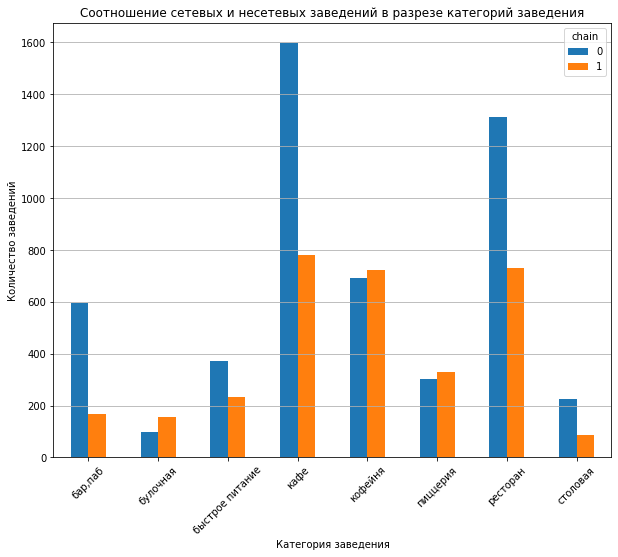

In [77]:
grouped_chain_category.plot.bar(figsize=(10, 8), rot=45, xlabel='Категория заведения', ylabel='Количество заведений', title='Соотношение сетевых и несетевых заведений в разрезе категорий заведения').grid(axis='y')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Вот так более наглядно, среди каких категорий заведений преобладают сетевые.</font>
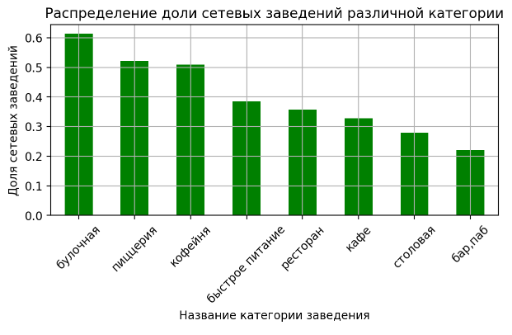

Изучим относительное распределение сетевых заведений по категориям заведений.

In [78]:
grouped_chain_1 = df.groupby(by='category')['chain'].value_counts(normalize = True).unstack()[1].sort_values(ascending=False)
grouped_chain_1

category
булочная           0.611765
пиццерия           0.521327
кофейня            0.509901
быстрое питание    0.384743
ресторан           0.357668
кафе               0.327862
столовая           0.279365
бар,паб            0.220915
Name: 1, dtype: float64

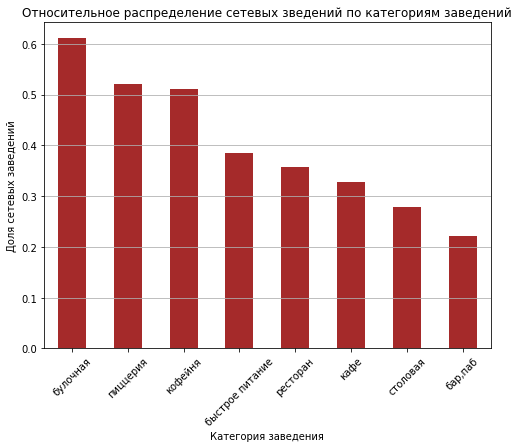

In [79]:
grouped_chain_1.plot(kind='bar', title='Относительное распределение сетевых зведений по категориям заведений', rot=45, xlabel='Категория заведения', ylabel='Доля сетевых заведений', color='brown', figsize=(8, 6)).grid(axis='y')

По графикам можно сделать следующие выводы:
- для категорий `булочная`, `кофейня`, `пиццерия` над количеством несетевых заведений преобладает количество сетевых (сетевых заведений примерно 61%, 52%, 51% соот-но), для остальных категорий ситуация обратная;
- для `баров, пабов` характерно наибольшее преобладание более чем в 3 раза несетевых заведений над сетевыми (сетевых заведений примерно 22%);
- для `кофеен` и `пиццерий` характерное примерное равенство сетевых и несетевых заведений.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, сделали промежуточный вывод по сетевым и не сетевым заведениям и категориям сетевых заведений.</font>

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.4-bullet"></a>
### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


Отберем строки, где элементы не были заменены значениями-индикаторами.

In [80]:
df_seats = df[df['seats'] != -1]

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что не забыли отфильтровать заглушку (значение-индикатор).</font>

Построим гистограмму и диаграмму размаха для исследования столбца.

In [81]:
# старый код
# min_value = df_seats['seats'].min()
# max_value = df_seats['seats'].max()

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Правильно было бы посмотреть сводную статистику  методом `describe()`.</font>

In [82]:
min_value = df_seats['seats'].describe()['min']
max_value = df_seats['seats'].describe()['max']
print(min_value, max_value)

0.0 1288.0


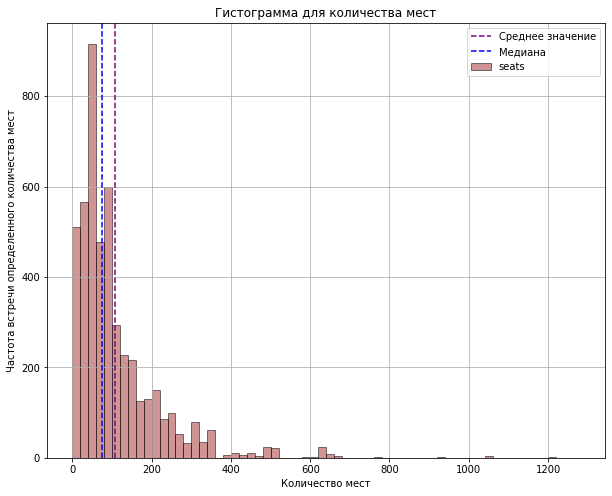

In [83]:
df_seats['seats'].plot(kind='hist', title='Гистограмма для количества мест', figsize=(10, 8), bins=range(int(min_value), int(max_value) + 1, 20), color='brown', alpha=0.5, edgecolor='black', grid=True, legend=True)
plt.xlabel('Количество мест')
plt.ylabel('Частота встречи определенного количества мест')
plt.axvline(df_seats['seats'].mean(), linewidth=1.5, label='Среднее значение', linestyle='--', color='purple')
plt.axvline(df_seats['seats'].median(), linewidth=1.5, label='Медиана', linestyle='--', color='blue')
plt.legend()

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, гистограмма показывает распределение посадочных мест в заведениях, разброс данных и форму распределения.</font>

Построим диаграмму размаха сначала с отображением выбросов, а потом без отображения выбросов (так как выбросов много, надо исключить проблему отображения основной массы данных).

Изменим множитель IQR на 3, так как данные сильно вариабельны, чтобы не исключить на самом деле корректные значения. 

Text(0.5, 0, 'Количество мест')

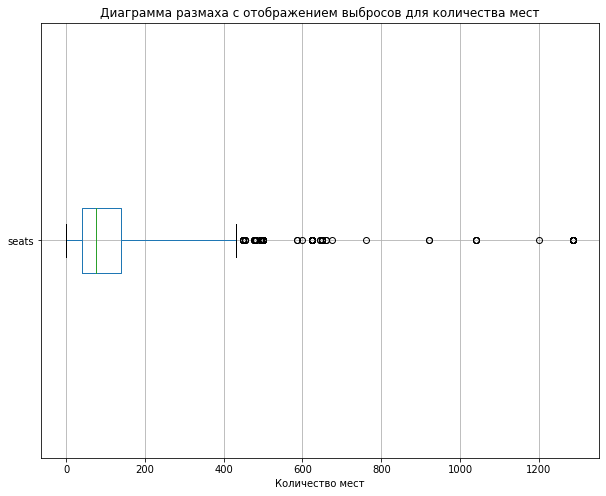

In [84]:
df_seats.boxplot('seats', vert=False, figsize=(10, 8), whis=3) 
plt.title('Диаграмма размаха с отображением выбросов для количества мест')
plt.xlabel('Количество мест')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 В разделе предобработки данных на пропуски значений посадочных мест была поставлена заглушка, при анализе ее необходимо отфильтровывать, так как она искажает результаты анализа.</font>

Text(0.5, 0, 'Количество мест')

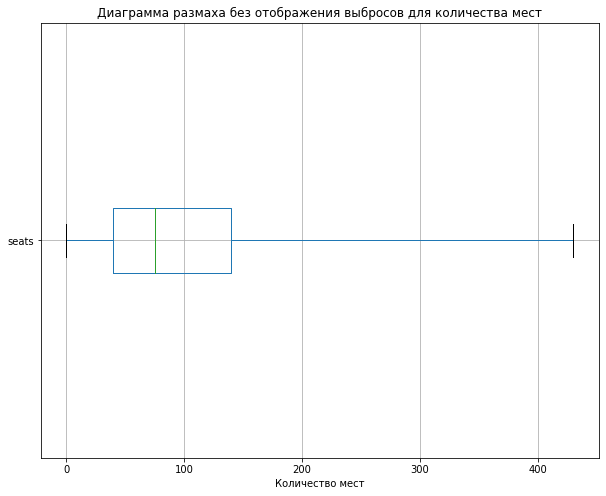

In [85]:
df_seats.boxplot('seats', vert=False, figsize=(10, 8), showfliers=False, whis=3) 
plt.title('Диаграмма размаха без отображения выбросов для количества мест')
plt.xlabel('Количество мест')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Тут аналогичная ошибка. </font>

Распределение столбца с количество мест правоассиметричное, среднее значение находится правее медианы, медиана смещена к началу распределения (около 20). Данные вариативны, так как при построении диаграммы пришлось увеличить множитель IQR из-за наличия некорректно большого количества выбросов, которые скорее всего таковыми не являются. 

В данных имеется большое количество выбросов в правой части, наличие которых может быть связано с ошибками сбора данных либо в частных случаях с наличием у заведений очень большого количества мест. 

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 А заведения питания в спортивно-концертных комплексах или фуд-корты не могут иметь такое большое количество посадочных мест?</font>

In [86]:
# Старый код

# Найдем для каждой категории заведений наиболее типичное количество посадочных мест с помощью моды.
# grouped_typical_seats = df_seats.groupby('category')['seats'].agg(pd.Series.mode).sort_values()
# grouped_typical_seats

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Фаст-фуд без посадочных мест?</font>

In [87]:
# grouped_typical_seats.plot(kind='bar', title='Наиболее типичное кол-во мест для категорий заведений', xlabel='Категория заведения', ylabel='Мода', color='brown', rot=45, figsize=(10, 8)).grid(axis='y')

In [88]:
# Старый анализ: Наиболее типичное количество мест для `булочной` и заведений `быстрое питание` равно 0, вероятно, это заведения, где предусмотрена только покупка еды, без приема пищи. `Кафе`, `пиццерии` и `столовой` свойствено 40 мест, `барам, пабам` - 60 мест, `кофейне` и `ресторанам` - 100 поадочных мест.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Не корректный анализ.</font>
<br><font color='DarkMagenta'>👉 Мода — это значение, которое встречается чаще всего в наборе данных. Медиана — это серединное значение, когда данные упорядочены по возрастанию. Среднее — это сумма всех значений, делённая на их количество.<br>
В датасете данные по количеству посадочных мест в разных категориях заведений, возможно, в каждой категории разное количество заведений, и их размеры (число мест) могут сильно варьироваться.<br>
Если использовать среднее значение, то на него могут сильно влиять выбросы, которые есть в датасете. Следовательно, среднее будет завышено, что не отражает типичный размер заведения. В таком случае медиана будет лучше, так как она устойчива к выбросам и показывает среднее положение в данных.<br>
Мода же показывает наиболее часто встречающееся количество мест. Это полезно, если нужно понять, какой размер заведений наиболее распространён в категории. Например, если большинство кафе имеют 20 посадочных мест, мода будет 20, даже если есть пара больших кафе с 100 местами.<br>
Но нужно учитывать, что мода может быть неинформативной, если все значения уникальны или есть несколько мод. Например, если в категории нет повторяющихся значений, мода не даст полезной информации. В таком случае медиана предпочтительнее.<br>
Также стоит иметь ввиду цель анализа. В задании брифа стоит цель `Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест`. То есть цель определить типичный размер заведения для планирования, то медиана даст представление о среднем размере, не искажённом выбросами. Если же цель — понять наиболее популярный или распространённый размер, то тут используем моду.<br>
Кроме того, распределение данных так же важно. Если распределение симметричное, среднее и медиана будут близки. Если же распределение скошено, как в данном случае, медиана лучше отражает центральную тенденцию.<br><br>
Резюме:<br>
- <b>Медиану</b> используют, когда данные имеют выбросы или асимметричное распределение, чтобы получить устойчивую оценку центральной тенденции, для понимания типичного количества мест без влияния очень больших или маленьких заведений.
- <b>Моду</b> применяют, чтобы определить наиболее распространённое значение в наборе данных, если нужно узнать, какой размер заведений чаще всего встречается в каждой категории.
    
В отчётах часто приводят и среднее, и медиану, и моду для более полной картины, но акцент делают на той мере, которая наиболее релевантна поставленному вопросу.</font>

Найдем для каждой категории заведений наиболее типичное количество посадочных мест с помощью медианы.

In [89]:
grouped_typical_seats = df_seats.groupby('category')['seats'].median().sort_values(ascending=False)
grouped_typical_seats

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

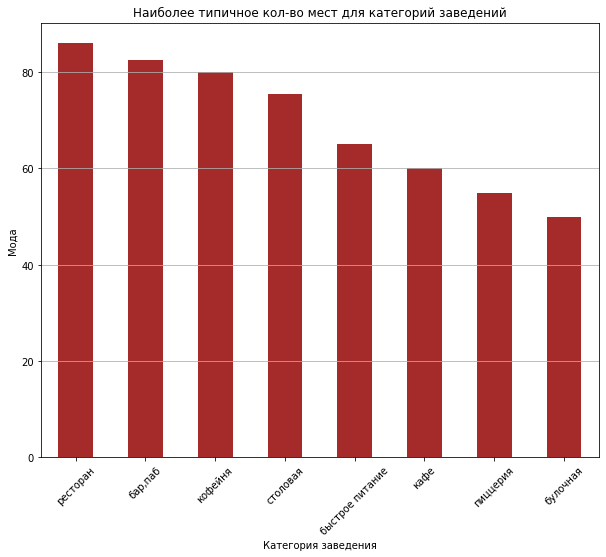

In [90]:
grouped_typical_seats.plot(kind='bar', title='Наиболее типичное кол-во мест для категорий заведений', xlabel='Категория заведения', ylabel='Мода', color='brown', rot=45, figsize=(10, 8)).grid(axis='y')

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Правильно, что для анализа посадочных мест по категориям заведений использованы медианные значения, так  как распределение данных имеет выбросы и ассимметрично. </font><br>
<font color='DarkMagenta'>👉 Не корректное оформление диаграммы.</font>
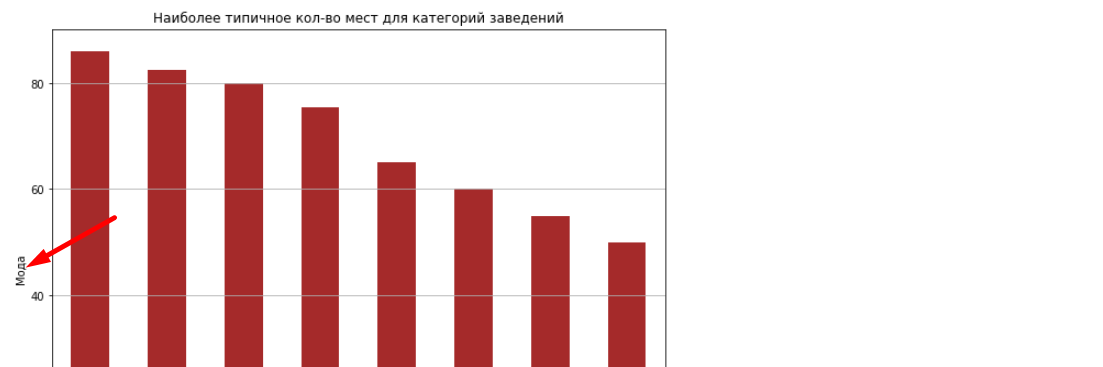

Наиболее типичное количество мест для заведений варьируется от 50 до 85. Наименьшее количество заведений - примерно 50 - характерно для булочных, наибольшее количество заведений - примерно 85 - для ресторанов.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.5-bullet"></a>
### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Правильно было бы посмотреть сводную статистику рейтингов всех заведений общественного питания  методом `describe()`.</font>
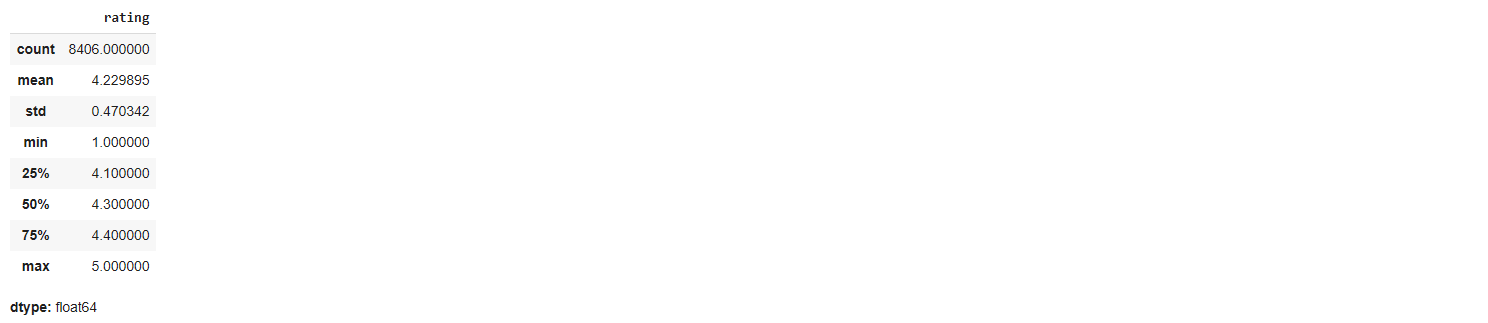

In [91]:
# Старый код

# Построим гистограмму для столбца `rating`. Исследуем рейтинг заведений.

# df['rating'].plot(kind='hist', title='Гистограмма для рейтинга заведений', color='brown', figsize=(8, 6), grid=True)
# plt.xlabel('Оценка')
# plt.ylabel('Количество оценок')

# Из гистограммы видно, что график имеет левоассиметричное распределение. Наиболее редко встречаются оценки от 1 до 3, причем реже всего - оценки около 2, что говорит о том, что на рынке все-таки присутствуют некачественные заведения, но их количество значительно меньше по сравнению с хорошими заведениями. 

# Наиболее часто встречаются положительные оценки от 3,75 до 5. Самая частая оценка составляет от 4,25 до 4,6 (примерно около 4400 оценок). 

Исследуем рейтинги заведений

In [92]:
df['rating'].describe()

count    8402.000000
mean        4.230016
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

По сводной информации можно увидеть, что значения рейтингов варьируются в пределах от 1 до 5, среднее значение рейтинга составляет примерно 4,2. Медиана равна 4,3, то есть 50% оценок выше этой отметки.

Посмотрим на распределение средних рейтингов по категориям заведений.

In [93]:
# Старый код
# grouped_rating = df.groupby('category')['rating'].mean().sort_values()
# grouped_rating

In [94]:
grouped_rating = df.groupby('category')['rating'].describe()['mean'].sort_values(ascending=False)
grouped_rating

category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290348
кофейня            4.277157
булочная           4.269020
столовая           4.211429
кафе               4.124284
быстрое питание    4.050249
Name: mean, dtype: float64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Следовало проанализировать вариации средних рейтингов по категориям заведений, для этого следует использовать метод `.describe()`. Примерно вот так:</font>
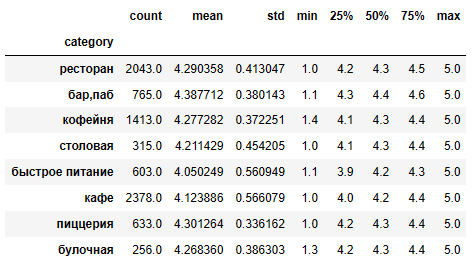

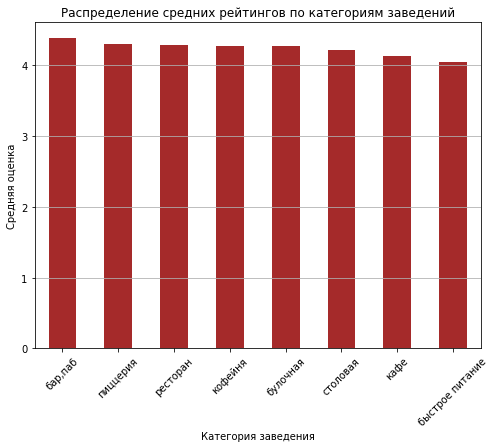

In [95]:
grouped_rating.plot(kind='bar', xlabel='Категория заведения', ylabel='Средняя оценка', rot=45, title='Распределение средних рейтингов по категориям заведений', figsize=(8, 6), color='brown').grid(axis='y')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошая визуализация столбчатой диаграммой рейтинга заведений по категориям.</font>

Средние рейтинги в зависимости от категории заведения варьируются в пределах от 4 до 4,4. Заведения быстрого питания имеют наименьший средний рейтинг (примерно 4), а бары и пабы - наибольший (примерно 4,5). Таким образом, клиенты баров и пабов в среднем остаются более удовлетворены сервисом и блюдами, нежели посетители других заведений.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Обращаю внимание, что диапазон изменения рейтинга от 1 до 5 и разница в 0.5 балла означает разницу в более чем 10%.<br> 
Это может говорить о:
- Различии в качестве обслуживания,
- Уровне удовлетворенности клиентов,
- Конкурентных преимуществах.

А значимость отличия средних значений рейтинга по разным категориям можно проверить другими методами.
</font>

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.6-bullet"></a>
### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [96]:
# Старый код

# Построим матрицу корреляции.
# correlation_matrix = df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()
# correlation_matrix

Создадим копию датасета и заменим заглушки на пропуски.

In [97]:
df_copy = df.copy()

Заменим заглушки на пропуски.

In [98]:
df_copy['hours'] = df_copy['hours'].replace('', np.nan)
df_copy['hours'].isna().sum()

537

In [99]:
df_copy['price'] = df_copy['price'].replace('', np.nan)
df_copy['price'].isna().sum()

5087

In [100]:
df_copy['middle_avg_bill'] = df_copy['middle_avg_bill'].replace(-1, np.nan)
df_copy['middle_avg_bill'].isna().sum()

5253

In [101]:
df_copy['seats'] = df_copy['seats'].replace(-1, np.nan)
df_copy['seats'].isna().sum()

3610

<font color='DarkBlue'><b>Комментарий ревьюера 3</b></font><br><font color='DarkMagenta'>👉 В итоге, заполнение пропусков заглушками создало проблемы при анализе.</font><br>
<font color='DarkMagenta'>👉 Заполнять пропуски или нет.<br><br>
<b>Когда пропуски можно оставить не заполненными:</b><br>
<b><i>Неважность пропущенных данных.</b></i> Если пропущенные значения не играют решающей роли в анализе и не влияют на выводы, пропуски можно оставить пустыми. Особенно актуально, если они касаются второстепенных признаков.<br>
<b><i>Высокий процент пропусков.</b></i> Если пропуски составляют значительный процент (например, более 30–40%) и заполнить их корректно затруднительно, лучше оставить пропуски как есть, чтобы избежать искажения данных.<br>
<b><i>Экспериментальные данные.</b></i> В случае, когда исследование направлено на выявление шаблонов или тенденций, пропуски могут использоваться как индикатор недостатка информации, что само по себе является важным сигналом.<br>
<b><i>Фильтрация данных.</b></i> Если последующий анализ предусматривает фильтрацию или агрегацию данных, пропуски могут быть просто исключены из анализа без последствий.<br>
<b><i>Ранжирование или классификация.</b></i> При проведении классификации или ранжирования пропуски могут оставаться пустыми, если они не участвуют в формировании ключевых признаков.<br><br>
<b>Когда пропуски желательно заполнять значениями-индикаторами:</b><br>
<b><i>Небольшое количество пропусков.</b></i> Если пропуски редко встречаются (например, менее 5%), их можно заполнить специальным значением, например, "_MISSING_", чтобы отразить их наличие.<br>
<b><i>Специальные потребности модели.</b></i> Некоторые алгоритмы машинного обучения (например, Random Forest, LightGBM) поддерживают пропуски, но предпочитают иметь дополнительные сигналы, такие как значение-индикатор, чтобы точнее учитывать их влияние.<br>
<b><i>Маркетинговые или социальные исследования.</b></i> В маркетинговых и социальных исследованиях пропуски могут нести важную информацию о поведении аудитории (например, отказ указать контактную информацию может сигнализировать о недоверии).<br>
<b><i>Классификация и сегментация.</b></i> В задачах классификации или сегментации наличие пропуска может стать отдельным признаком, помогающим улучшить точность модели.<br>
<b><i>Специфичность признаков.</b></i> Если знак пропусков важен для понимания поведения или характеристик данных (например, "отсутствие информации" свидетельствует о низкой активности пользователя), полезно использовать значение-индикатор.<br>
<i>Выбор подхода зависит от специфики задачи и целей анализа.</i></font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font>
<br><font color='Red'>🛠 В разделе предобработки на пропуски в данных были поставлены заглушки и расчет корреляции проводится с ними, соответственно, является не валидным. Но просто отфильтровать заглушки нельзя, так будут одновременно удалены значимые данные по другим столбцам датасета и опять получим невалидный анализ.<br>В данном случае, чтобы не переделывать раздел предобработки, исправить ошибку можно только, создав копию датасета и в ней заменить заглушку на пропуски. Пропуски не мешают расчету корреляции.</font>

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='Red'>🛠 Ошибка не исправлена. Расчет производится неправильно, с заглушкой в посадочных местах, см.код ниже.</font>

In [102]:
# Комментарий ревьюера 2
df_copy.seats.min()

0.0

Создадим матрицу корреляции

In [103]:
correlation_matrix = df_copy[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()
correlation_matrix

interval columns not set, guessing: ['rating', 'chain', 'seats']


,rating,category,district,chain,seats,price,is_24_7
rating,1.000000,0.198835,0.189453,0.119212,0.000000,0.262056,0.161010
category,0.198835,1.000000,0.174386,0.265325,0.048661,0.566933,0.244853
district,0.189453,0.174386,1.000000,0.064447,0.352440,0.202787,0.076357
chain,0.119212,0.265325,0.064447,1.000000,0.057584,0.218211,0.043227
seats,0.000000,0.048661,0.352440,0.057584,1.000000,0.088146,0.043193
price,0.262056,0.566933,0.202787,0.218211,0.088146,1.000000,0.084183
is_24_7,0.161010,0.244853,0.076357,0.043227,0.043193,0.084183,1.000000


In [104]:
# оставим значения только для рейтинга
correlation_rating = pd.DataFrame(correlation_matrix['rating'][1:].sort_values())
correlation_rating

,rating
seats,0.000000
chain,0.119212
is_24_7,0.161010
district,0.189453
category,0.198835
price,0.262056


<font color='DarkBlue'><b>Комментарий ревьюера 3</b></font><br>
<font color='DarkGreen'>👌 Правильно построена корреляционная матрица с использованием библиотеки `phik`, это позволяет не обращать внимание на линейность и не линейность взаимозависимости признаков и не использовать для них отдельные методы.</font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Необходимо визуализировать корреляционную матрицу тепловой картой.</font>

Text(0.5, 15.0, 'Рейтинг')

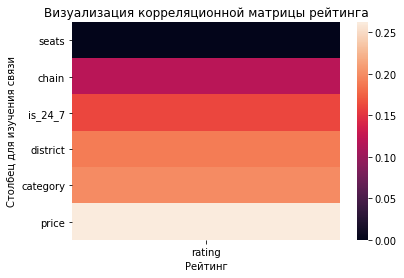

In [105]:
sns.heatmap(correlation_rating)
plt.title('Визуализация корреляционной матрицы рейтинга')
plt.ylabel('Столбец для изучения связи')
plt.xlabel('Рейтинг')

<font color='DarkBlue'><b>Комментарий ревьюера 3</b></font><br>
<font color='DarkGreen'>👌 Правильно визуализирована корреляционная матрица.</font>

Рейтинг со всеми столбцами показывает довольно слабую корреляцию. Наиболее сильная корреляция со столбцом `price` - примерно 0,25. Проверим ее.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Необходимо вывести расчет значения среднего рейтинга для разных ценовых категорий заведений.</font>

Найдем средний рейтинг для разных ценовых категорий заведений.

In [106]:
grouped_rating_price = df_copy.groupby('price')['rating'].mean().sort_values()
grouped_rating_price

price
низкие           4.173077
средние          4.297874
выше среднего    4.386348
высокие          4.436611
Name: rating, dtype: float32

<font color='DarkBlue'><b>Комментарий ревьюера 3</b></font><br>
<font color='DarkGreen'>👌 Хорошо, рассчитаны значения среднего рейтинга для разных ценовых категорий заведений.</font>

<AxesSubplot:title={'center':'Зависимость рейтинга от ценовой категории заведения'}, xlabel='Ценовая категория', ylabel='Средний рейтинг'>

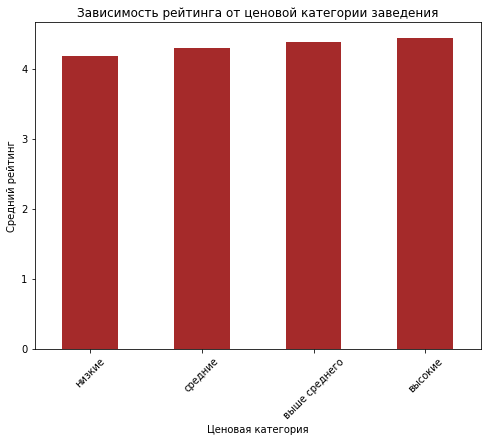

In [107]:
grouped_rating_price.plot(kind='bar', title='Зависимость рейтинга от ценовой категории заведения', xlabel='Ценовая категория', ylabel='Средний рейтинг', rot=45, color='brown', figsize=(8, 6))

<font color='DarkBlue'><b>Комментарий ревьюера 3</b></font><br>
<font color='DarkGreen'>👌 Хорошая визуализация значения среднего рейтинга для разных ценовых категорий заведений.</font>

Можно увидеть, что средний рейтинг зависит от ценовой категории. Чем выше ценовая категория заведений, тем выше средний рейтинг. Так, заведениям с низкими ценами соответствует рейтинг примерно 4.1, а заведениям с высокими ценами - примерно 4.5. 

<font color='DarkBlue'><b>Комментарий ревьюера 3</b></font><br>
<font color='DarkGreen'>👌 Хорошо, описали анализ взаимосвязи рейтинга заведений с ценовой категорией заведений.</font>

In [108]:
# df.plot(kind='scatter', x='price', y='rating', title='Зависимость рейтинга и ценовой категории', xlabel='Ценовая категория', ylabel='Рейтинг', color='brown', figsize=(10, 8))

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Данная визуализация диаграммой рассеяния не позволяет оценить рейтинг, так как каждая точка на графике означает данные по одному заведению. И сколько таких заведений находится в интервале рейтинга от 4 до 5 по диаграмме опредилить не возможно, а их количество может превышать количество заведений по другим категориям. Здесь уместна столбчатая диаграмма по среднему рейтингу.</font>

In [109]:
# Старый анализ 
# Можно увидеть, что высокой ценовой категории принадлежат в основном наилучшие оценки, средней - одни из самых низких.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Не правильный расчет корреляции. Необходимо переделать весь этот раздел, сделать анализ и визуализацию признака с самой сильной связью с рейтингом, сделать выводы.</font>

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='Red'>🛠 Ошибка не исправлена. Не правильный расчет корреляции. Необходимо переделать весь этот раздел.</font>

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.7-bullet"></a>
### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Параллельно посчитаем для них средний рейтинг.

In [110]:
# создадим датафрейм с сетями
df_chain = df[df['chain'] == 1]
grouped_name = df_chain.groupby(by=['name', 'category']).agg({'address': 'count', 'rating': 'mean'}).sort_values(by='address', ascending=False).head(15).reset_index().sort_values(by='rating').rename(columns={'address':'count_objects', 'rating': 'mean_rating'})
grouped_name

,name,category,count_objects,mean_rating
4,яндекс лавка,ресторан,69,3.872464
11,чайхана,кафе,26,3.946154
10,cofefest,кофейня,31,3.977419
13,drive café,кафе,24,4.025000
3,one price coffee,кофейня,71,4.064789
5,cofix,кофейня,65,4.075385
9,теремок,ресторан,36,4.105556
6,prime,ресторан,49,4.114285
7,кофепорт,кофейня,42,4.147619
1,домино'с пицца,пиццерия,76,4.169737


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Хочу обратить внимание, что код выше не совсем корректен, так как группировка проводится только по имени заведения, а должна по имени и категории. В итоге, в таблицу попадают заведения, которые имеют несколько категорий, см.код ниже. На скрине таблица топ-15 сгруппированная одновременно по имени и категории.</font>
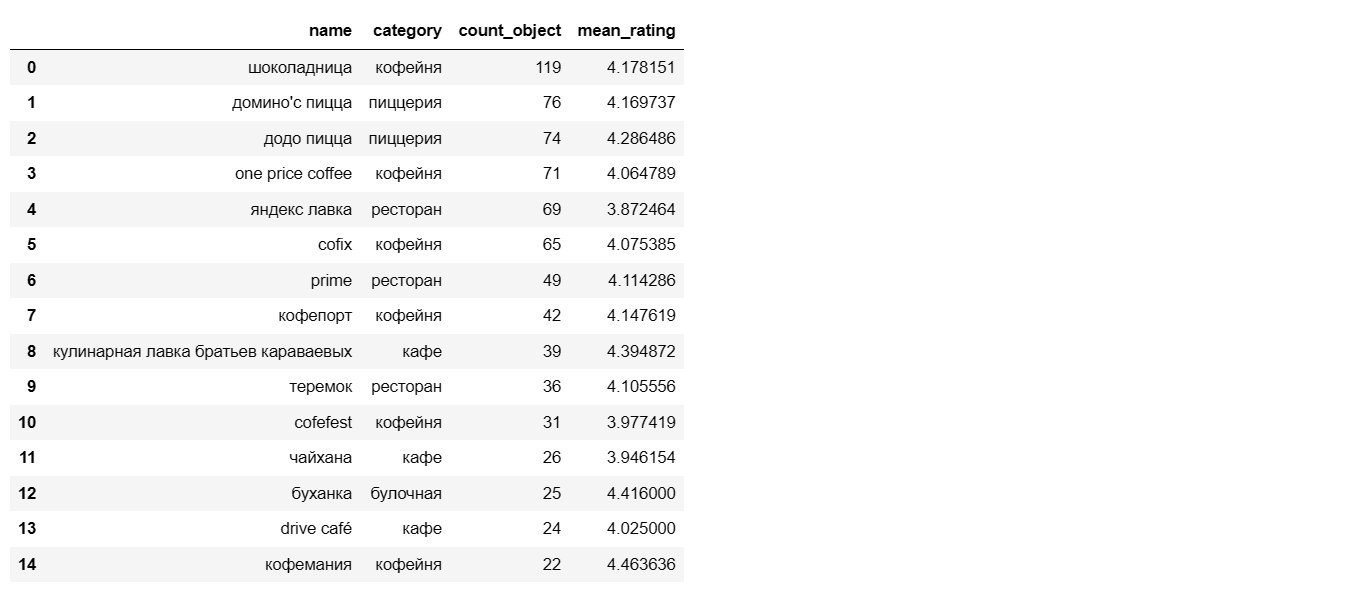

In [111]:
# Комментарий ревьюера
tmp = df.copy()          # создаем копию текущего датасета
name_tmp = 'му-му'       # задаем имя столбца для проверки уникальных категорий
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name == name_tmp].category.unique())}')

Заведения с одинаковым именем му-му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


Text(0, 0.5, 'Название сети заведений')

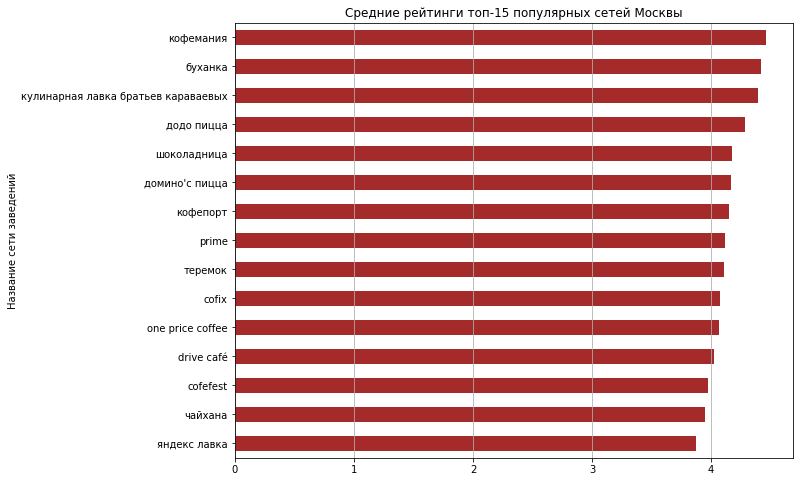

In [112]:
grouped_name.plot(kind='barh', x='name', y='mean_rating', xlabel='Название сети заведений', legend=False, color='brown', title='Средние рейтинги топ-15 популярных сетей Москвы', figsize=(10, 8), rot=0).grid(axis='x')
plt.ylabel('Название сети заведений')

Средние рейтинги топ-15 популярных сетей Москвы варируются в пределах от 3.8 до 4.5. Наибольший рейтинг присущ сети "Кофемания", наименьший - сети "Яндекс лавка".

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Лучше строить горизонтальную столбчатую диаграмму средних рейтингов сетевых заведений. Так удобнее визуально сравнивать данные.</font>
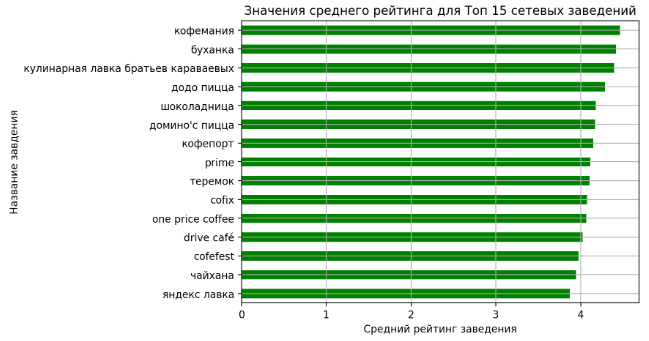

Визуализируем количество заведений каждой сети.

In [113]:
# отсортируем по количеству заведений
grouped_name = grouped_name.sort_values(by='count_objects')
grouped_name

,name,category,count_objects,mean_rating
14,кофемания,кофейня,22,4.463636
13,drive café,кафе,24,4.025000
12,буханка,булочная,25,4.416000
11,чайхана,кафе,26,3.946154
10,cofefest,кофейня,31,3.977419
9,теремок,ресторан,36,4.105556
8,кулинарная лавка братьев караваевых,кафе,39,4.394872
7,кофепорт,кофейня,42,4.147619
6,prime,ресторан,49,4.114285
5,cofix,кофейня,65,4.075385


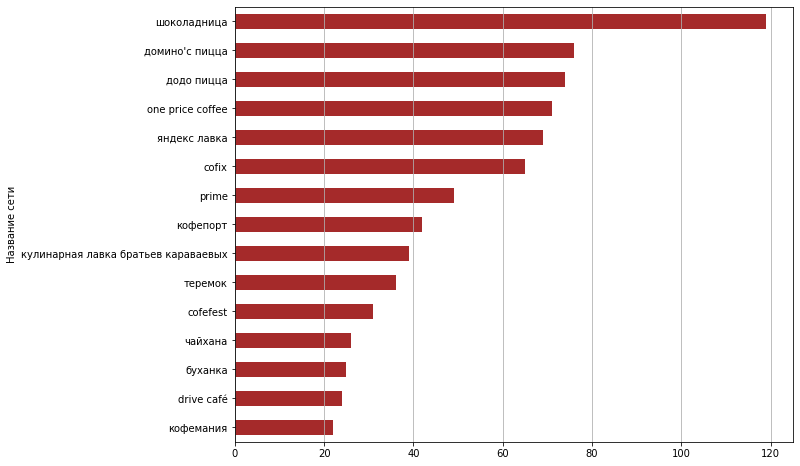

In [114]:
grouped_name.plot(kind='barh', x = 'name', y='count_objects', color='brown', figsize=(10, 8), xlabel='Название сети', ylabel='Количество заведений', rot=0, legend=False).grid(axis='x')

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Хорошо, теперь правильно.</font>

Наибольшее количество заведений у топ-15 сетей принадлежит сети "Шоколадница" и составляет примерно 120 точек. Наименьшее количество заведений присуще сети "Кофемания" и составляет 22 заведения. 

In [115]:
# создадим пары "название заведения - категория"
# df_category_for_top = df[['name', 'category']]
# df_category_for_top = df_category_for_top.drop_duplicates()
# df_category_for_top
# grouped_name = grouped_name.merge(df_category_for_top, how='left', on='name')
# grouped_name

Найдем уникальные значения категорий топ-15 заведений.

In [116]:
grouped_name['category'].unique()

array(['кофейня', 'кафе', 'булочная', 'ресторан', 'пиццерия'],
      dtype=object)

Таким образом, топ-15 сетям принадлежат такие категории заведений, как `кофейня`, `кафе`, `булочная`, `ресторан` и `пиццерия`. Наибольший рейтинг, равный примерно 4.5, принадлежит сети заведений "Кофемания", имеющей наименьшее количество точек, равное 22. Наименьший рейтинг, равный примерно 3.8, принадлежит сети "Яндекс лавка", количество заведений которой равно примерно 70. Наибольшее количество точек, равное примерно 120, принадлежит "Шоколаднице", рейтинг которой около 4.2. 

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Нет визуализации количества топ-15 сетевых заведений, что требуется в задании.</font><br>
<font color='Red'>🛠 Задание должно заканчиваться промежуточными выводами анализа топ-15 сетевых заведений.</font>

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.8-bullet"></a>
### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


Отсортируем датафрейм, оставив только данные, не заполненные значениями-индикаторами.

In [117]:
df_avg_bill = df[df['middle_avg_bill'] != -1]

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что не забыли отфильтровать заглушку (значение-индикатор).</font>

Проанализируем статистические показатели данных по среднему чеку заведений. 

In [118]:
df_avg_bill['middle_avg_bill'].describe()

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

Среднее значение по столбцу со средним чеком заведений примерно равно 960. Значения столбца варьируются в пределах 35000. 50% данных имеют значения больше 750. Среднеквадратичное отклонение равно примерно 1010. 

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Следовало проанализировать статистические показатели данных по среднему чеку заведений методом `.describe()`.</font><br>
<font color='Red'>🛠 Следует визуализировать анализ среднего чека заведений гистограммой и диаграммой размаха, для оценки размаха распределения, его симметричности и наличия выбросов. Примерно вот так:</font>
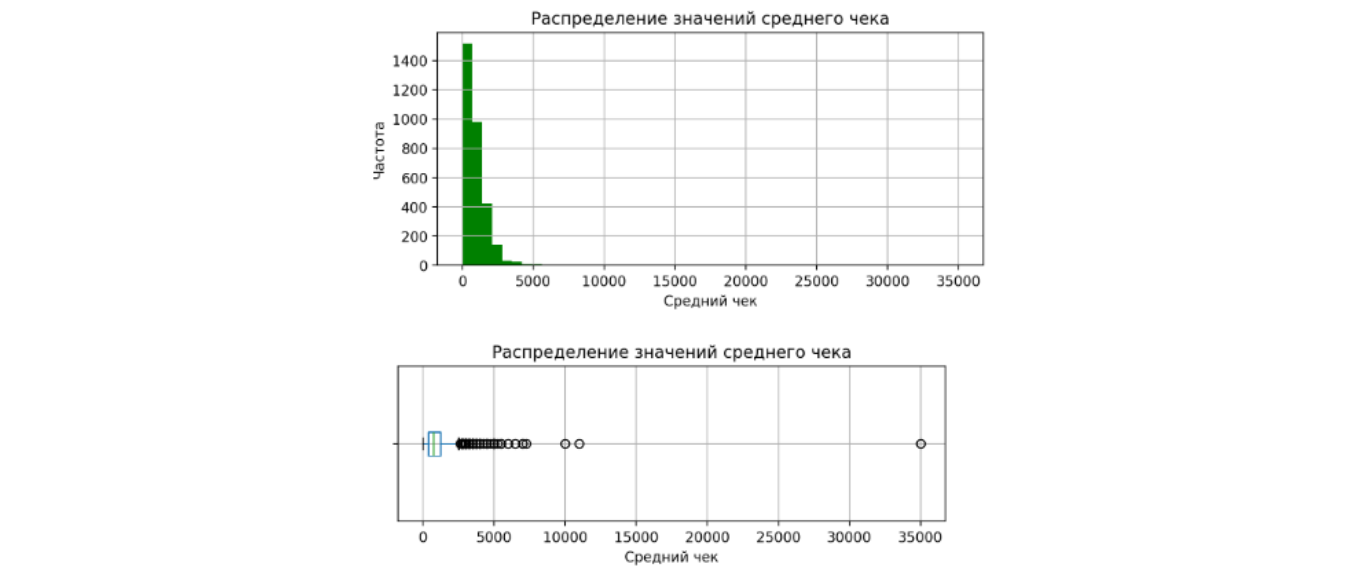

Построим гистограмму и диаграмму размаха с выбросами и без выбросов для столюца со средним чеком заведений.

Text(0.5, 1.0, 'Гистограмма для столбца со средним чеком')

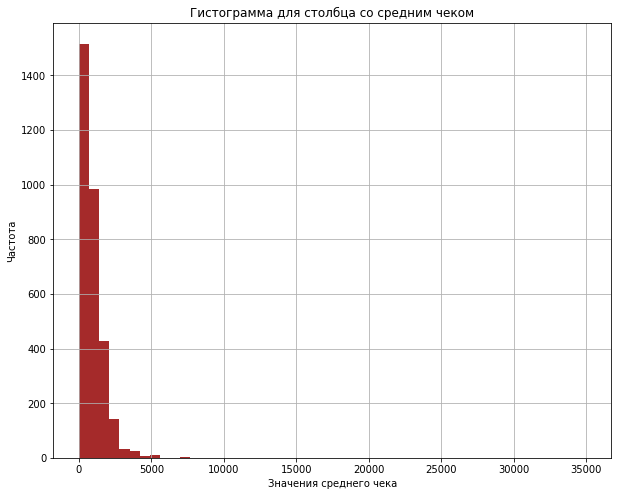

In [119]:
df_avg_bill['middle_avg_bill'].plot(kind='hist', bins=50, color='brown', figsize=(10, 8), legend=False, grid=True)
plt.ylabel('Частота')
plt.xlabel('Значения среднего чека')
plt.title('Гистограмма для столбца со средним чеком')

Распределение столбца со средним чеком правоассиметричное, среднее значение расположено правее медианы, большинство значений расположено в диапазоне от 0 до 5000.

Text(0.5, 1.0, 'Диаграмма размаха без выбросов для столбца со средними значениями чека')

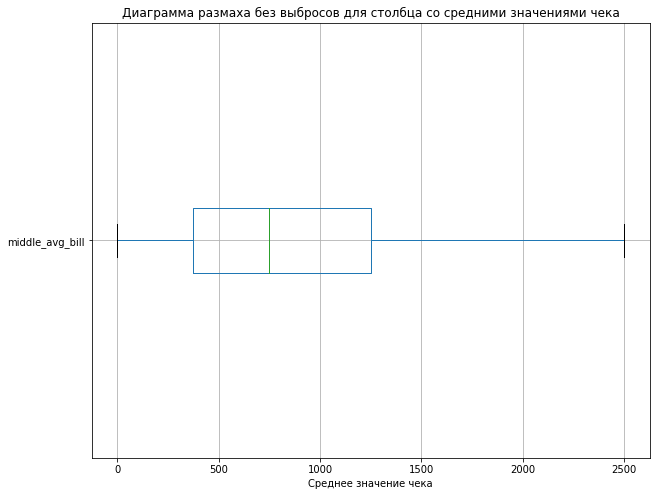

In [120]:
df_avg_bill.boxplot('middle_avg_bill', vert=False, figsize=(10, 8), showfliers=False)
plt.xlabel('Среднее значение чека')
plt.title('Диаграмма размаха без выбросов для столбца со средними значениями чека')

Text(0.5, 1.0, 'Диаграмма размаха с выбросами для столбца со средними значениями чека')

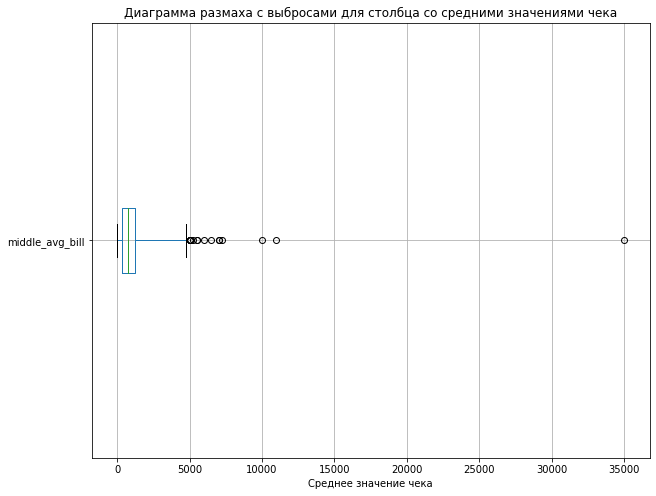

In [121]:
df_avg_bill.boxplot('middle_avg_bill', vert=False, whis=4, figsize=(10, 8))
plt.xlabel('Среднее значение чека')
plt.title('Диаграмма размаха с выбросами для столбца со средними значениями чека')

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkMagenta'>👉 Основной порядок анализа данных:<br>
Порядок анализа: <b>абсолютные значения → относительные значения → сводная статистика → визуализация (гистограмма и диаграмма размаха)</b>, обеспечивает постепенное углубление в данные, минимизирует ошибки интерпретации и помогает выявить ключевые закономерности.
1. <b>Вывод абсолютных значений:</b> Показывает «сырые» данные без преобразований (например, количество клиентов, выручка в рублях). Позволяет оценить масштаб данных, обнаружить явные аномалии (например, отрицательные значения там, где их быть не должно).
2. <b>Вывод относительных значений:</b> Нормализует данные для сравнения (проценты, доли, темпы роста). Помогает увидеть структуру и пропорции (например, доля категорий товаров в общей выручке).
3. <b>Вывод сводной статистики:</b> Обобщает данные через ключевые метрики:<br>
<i>Среднее</i> — центральная тенденция.<br>
<i>Медиана</i> — устойчивая к выбросам оценка.<br>
<i>Стандартное отклонение</i> — мера разброса.<br>
<i>Минимум/максимум</i> — границы данных.<br>
Выявляет асимметрию, разброс, выбросы.
4. <b>Построение гистограммы:</b> Визуализирует распределение данных. Показывает форму распределения (нормальное, бимодальное, скошенное). Выделяет частотные интервалы (например, большинство оценок сосредоточено в диапазоне 4.0–4.4).
5. <b>Диаграмма размаха (ящик с усами):</b> Отображает медиану, квартили, размах и выбросы. Позволяет сравнить распределения между группами (например, рейтинги). Точечно идентифицирует аномалии.<br><br>
<b>Почему такой порядок оптимален?</b>
- <i>От частного к общему:</i><br>
Абсолютные значения → контекст.<br>
Относительные → сравнение.<br>
Статистика → обобщение.<br>
Графики → инсайты.<br>

- <i>Минимизация ошибок:</i>
Сначала проверяются базовые метрики, чтобы исключить технические ошибки (например, некорректные данные). Визуализация на последнем этапе позволяет подтвердить или опровергнуть гипотезы, сформированные на предыдущих шагах.
- <i>Эффективность:</i>
Сводная статистика и графики требуют предварительной очистки данных, которую обеспечивают первые два этапа.
Такой подход обеспечивает системность, снижает риск пропустить важные детали и упрощает коммуникацию результатов.
</font>

Из диаграмм размаха так же видно, что распределение правоассиметричное, медиана смещена влево, размах равен 35000, данные вариабельны, из-за чего был увеличен множитель IQR для отражения выбросов. Имеется большое количество выбросов справа, в основном сосредоточенных в пределах от 5000 до 10000.

Изучим вариацию среднего чека заведения в зависимости от района Москвы.

In [122]:
# Старый код

# grouped_middle_avg_bill = df_avg_bill.groupby('district')['middle_avg_bill'].mean().sort_values().reset_index()
# grouped_middle_avg_bill['district'] = grouped_middle_avg_bill['district'].str.replace('административный округ', '')
# grouped_middle_avg_bill = grouped_middle_avg_bill.set_index('district')
# grouped_middle_avg_bill
#grouped_middle_avg_bill.plot(kind='bar', xlabel='Название района', ylabel='Средний чек', legend=False, color='brown', title='Зависимость среднего чека от района Москвы', figsize=(20, 8), rot=45).grid(axis='y')

In [123]:
grouped_middle_avg_bill = df_avg_bill.groupby(by='district')['middle_avg_bill'].describe()[['mean', '50%']].rename(columns={'50%':'median'}).sort_values(by='mean')
grouped_middle_avg_bill

,mean,median
district,,
юго-восточный административный округ,654.097961,450.0
северо-восточный административный округ,716.611267,500.0
юго-западный административный округ,792.561707,600.0
восточный административный округ,820.626953,575.0
северо-западный административный округ,822.222900,700.0
южный административный округ,834.398071,500.0
северный административный округ,927.959656,650.0
западный административный округ,1053.225464,1000.0
центральный административный округ,1191.057495,1000.0


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Более полный анализ центральной тенденции среднего чека заведений по административным округам был бы при выводе и медианы, и среднего значения среднего чека, примерно вот так:</font>
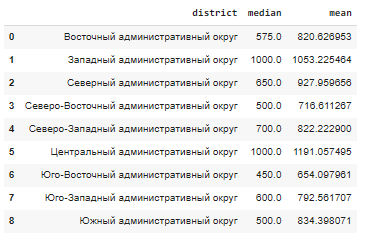

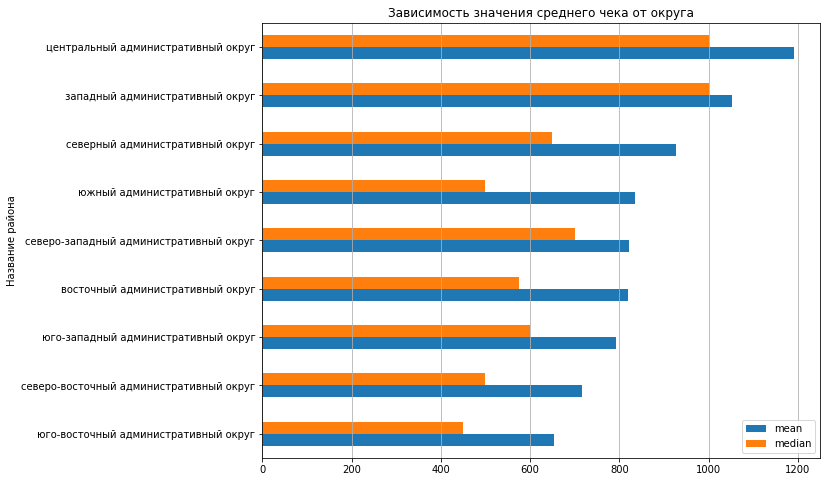

In [124]:
grouped_middle_avg_bill.plot.barh(xlabel='Название района', ylabel='Значение чека', title='Зависимость значения среднего чека от округа',  figsize=(10, 8)).grid(axis='x')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>Хорошо визуализированы значения среднего чека заведений по административным округам. Можно было вывести на диаграмму и медианы, и средние значения, примерно вот так:</font>
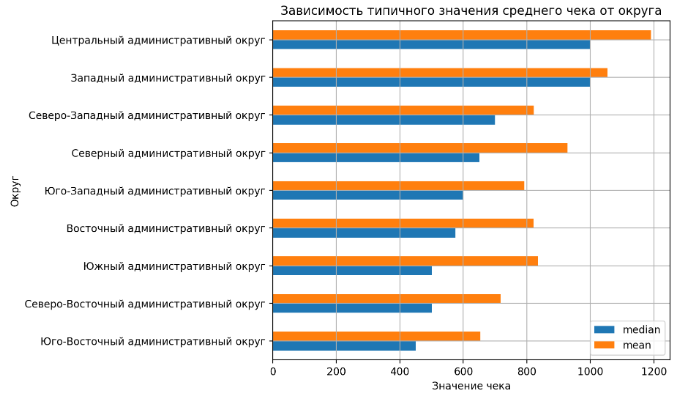

Наибольший средний чек присущ центральному району, вероятно, из-за того, что большинство заведений в центре - рестораны, ценовой сегмент которых оносится к "высоким". При этом по сравнению с другими количество ресторанов в целом преобладает в этом районе.  Заведения, не находящиеся в центре, имеют менее высокие чеки. Так, наименьший средний чек у юго-восточного и северо-восточного районов (в пределах 650-700). Причина снижения среднего чека, скорее всего, отдаление от центра и меньшее количество точек общественного питания. Все округи имеют правоассиметричное распределение, наиболее близко к симметричному распределению западный административный округ. Это говорит о том, что для каждого округа выбросы для столбца со средним чеком расположены справа, наименьшее количество выбросов присуще западному административному округу.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Необходимо более развернуто делать промежуточный вывод: в каких округах самый высокий средний чек и чем это можно объяснить, в каких округах минимальные выбросы по среднему чеку, где самые низкие значения среднего чека и как это можно интерпретировать. </font>

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

---
Обобщение полученных результатов:
- Наиболее частыми заведениями являются кофейни, рестораны и кафе;
- Наиболее редкими заведениями являются булочные, столовые и заведения быстрого питания;
- Наибольшее количество заведений сосредоточено в центральном районе, наименьшее - в северо-западном;
- Несетевых заведений примерно на 42% больше, чем сетевых по общим данным;
- Больше всего в своих категориях сетевых булочных, кофеен и пиццерий, меньше всего - сетевых баров, пабов;
- Наиболее типичное количество мест для заведений варьируется от 50 до 85. Наименьшее количество заведений - примерно 50 - характерно для булочных, наибольшее количество заведений - примерно 85 - для ресторанов;
- Все заведения в основном имеют хороший рейтинг от 4 до 4,4;
- Рейтинги не зависят от категории заведения, имеют небольшую зависимость от ценовой категории;
- У топ-15 распространенных сетевых заведений средние оценки находятся в диапазонах от 3,8 до 4,5;
- Наибольший чек достигается в центральном районе. 

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'> Правильно сделан промежуточный вывод по исследовательскому анализу данных заведений общественного питания.</font>

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="4-bullet"></a>
## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.
---
Целью и задачей выполнения проекта был анализ датасета, содержащего в себе данные о заведениях общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года, и предоставление инвесторам актуальной информации об объектах питания в Москве, чтобы они смогли подобрать оптимальный для себя тип заведения, его расположение и т.д. для открытия новой точки.

В результате работы были загружены и изучены данные датасетов rest_info.csv и rest_price.csv, подготовлен единый датафрейм для дальнейшего анализа. Датафрейм был предобработан: изменены типы данных, обработаны пропущенные значения, проведена проверка дубликатов, создан столбец `is_24_7` для дальнейшей работы. Путем рассмотрения гистограмм, столбчатых диаграмм, диаграмм размаха, тепловых карт; изучения зависимостей в числах, построени визуализаций в целом, была проведена обработка данных.

В ходе выполнения предобработка данных были:
- Изменены типы данных столбцов `rating`, `chain`, `seats`. Понижена раздрядность столбцов `middle_avg_bill`, `middle_coffee_cup`;
- Проанализированы причины пропусков во всех столбцах, предложены способы работы с пропусками. В столбцах `seats`, `hours`, `price`, `middle_avg_bill` проведены замены пропусков значениями-индикаторами;
- Нормализованы категориальные данные;
- Выявлено отсутствие явных дубликатов;
- Выявлено наличие 4 неявных дубликатов. Проведен анализ строк-неявных дубликатов, редактирование оставшихся после удаления строк, чтобы данные были не искажены.

Предобработка данных позволила получить корректные результаты при анализе данных. По анализу данных можно сформулировать следующие рекомендации для заказчиков. 

Выбор места для открытия заведения зависит в основном от решения инвесторов. Исходя из данных, наиболее прибыльные места сосредоточены в центральном районе, но при этом количество открытых точек там так же самое большое. В остальных районах количество объектов примерно одинаковое, но средний чек немного варьируется - после центрального района самый большой чек принадлежит западному району, самый маленький - юго-восточному. Рейтинг заведения будет зависеть от работы точки, так как нельзя сказать, что на него сильно влияют внешний факторы, за иклюением ценовой категории заведения - чем выше категория, тем выше будет средний чек. На рынке сетевых заведений меньше, чем несетевых, что оставляет больше пространства для развития новой сети заведений. Но при открытии сети необходимо учитывать и категорию заведения. Для одних категорий сетевые заведения более свойственны, для других - менее. Количество посадочных мест определяется владельцами, но при этом стоит учитывать типичные значения - так, рестораны и бары, пабы требуют большего количества мест, пиццерии и булочные - меньшего.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Вывод должен обобщать весь проект, включая раздел анализа и предобработки данных, и кратко суммировать промежуточные выводы разделов всего исследования.</font><br>
<font color='DarkMagenta'>👉 Общий вывод проекта должен содержать следующие основные моменты:<br>
- Краткое описание целей и задач проекта.<br>
- Основные результаты, полученные в ходе выполнения проекта.<br>
- Анализ всех разделов проекта, включая раздел анализа и предобработки данных, и их влияния на общие результаты.<br>
- Возможные направления дальнейшего развития и применения полученных результатов. Рекомендации заказчику.<br>
Общий вывод должен быть написан в логической последовательности и отражать общую картину проекта. Он должен быть кратким, но содержательным, чтобы заказчик мог получить полное представление о проекте и его значимости.</font>

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера</b></font><br><br>
<font color='DarkGreen'>👌 Анна, проект отлично структурирован и проработан.<br>Так держать и дальше!<br></font>
<font color='Red'>🛠 Что нужно, что бы сделать проект лучше:</font><br>
<font color='Red'>🛠 Сделать анализ пропусков в датасете, сделать предположения об их причинах и предложений по обработке пропусков. Сделать проверку неявных (неполных) дубликатов. Переделать выводы по первичному анализу и предобработке данных. Сделать анализ сетевых и несетевых заведений в относительных значениях, сделать визуализацию. В анализе посадочных мест необходимо отфильтровать заглушку. Переделать анализ типичного количества посадочных мест по категориям заведений, сделать выводы. Переделать анализ корреляции рейтинга с другими данными по заведениям, проанализировать самую сильную связь, сделать анализ и визуализацию, сделать выводы. Визуализировать количество топ-15 сетевых заведений. Сделать выводы по анализу топ-15 сетевых заведений. Визуализировать анализ среднего чека заведений гистограммой и диаграммой размаха. Написать развернутый итоговый вывод исследования.</font><br>
<font color='DarkMagenta'>👉 При исправлении ошибок и недочетов будут приобретены дополнительный опыт и навыки!</font><br>
<font color='DarkGreen'>👌 Жду окончательный вариант! Успехов.</font>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера 2</b></font><br><br>
<font color='DarkGreen'>👌 Анна, увы, остались еще ошибки.<br></font>
<font color='Red'>🛠 Что нужно доделать:</font><br>
<font color='Red'>🛠 Переделать анализ корреляции рейтинга с другими данными по заведениям.</font><br>
<font color='DarkGreen'>👌 Жду исправленный вариант! Успехов.</font>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера 3</b></font><br><br>
<font color='DarkGreen'>👌 Анна! Удалось справиться со всеми заданиями в проекте. Молодец! 😄 Спасибо за работу!<br>
Входе выполнения проекта научились проводить исследовательский анализ данных, определять когда необходимо анализировать медианы или средние значения и визуализировать анализ. В данном проекте акцентировано внимание, что анализ проводится в целях дальнейшего принятия бизнес-решения по открытию заведения общественного питания инвестиционным фондом.</font><br>
<font color='DarkGreen'>👌 Теперь, вперед за новыми знаниями и навыками! Удачи! 😉</font>
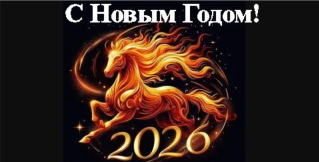